In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [11]:
df = pd.read_csv("df_markers_bioage__ano_cl.csv", parse_dates=["Data dell'Episodio"])

In [12]:
df

,id_num,Data dell'Episodio,Data di nascita,Età,Genere,Alanina aminotransferasi (ALT),Aspartato Aminotransferasi (AST),Colesterolo HDL,Colesterolo LDL,Colesterolo totale,Creatinina,Glucosio,Linfociti,Neutrofili,Piastrine,RDW-CV,Trigliceridi,Urea
0,1,2022-05-14,1966-09-19,55,M,26,21,37,167,222,0.78,129,2.23,4.28,257,13.4,185,31.0
1,2,2025-12-16,1940-05-27,85,M,33,24,81,34,130,1.11,108,1.02,4.58,231,14.0,66,45.0
2,3,2022-10-24,1968-03-20,54,F,21,20,41,110,158,0.80,181,2.67,4.51,358,15.9,208,28.0
3,4,2026-03-10,1968-05-11,57,F,16,16,71,113,191,0.74,86,1.51,2.55,248,12.7,71,21.0
4,5,2025-05-14,1977-01-14,48,F,11,20,78,111,206,0.78,96,1.34,2.66,211,12.8,44,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15713,12497,2026-03-27,1994-06-24,31,M,28,41,28,55,94,1.29,85,1.71,5.50,259,11.8,63,55.0
15714,479,2026-02-11,1970-04-08,55,F,20,21,68,125,208,0.69,86,2.18,2.52,309,12.9,71,48.0
15715,12498,2026-02-27,1948-04-03,77,F,18,22,59,73,147,0.91,92,0.46,2.99,244,12.7,166,40.0
15716,12499,2026-04-29,1964-06-15,61,F,17,18,72,126,216,0.77,137,1.60,2.80,251,12.2,95,48.0


In [13]:
df_non_duplicate = df.drop_duplicates(subset=['id_num'], keep='last')
df_non_duplicate

,id_num,Data dell'Episodio,Data di nascita,Età,Genere,Alanina aminotransferasi (ALT),Aspartato Aminotransferasi (AST),Colesterolo HDL,Colesterolo LDL,Colesterolo totale,Creatinina,Glucosio,Linfociti,Neutrofili,Piastrine,RDW-CV,Trigliceridi,Urea
0,1,2022-05-14,1966-09-19,55,M,26,21,37,167,222,0.78,129,2.23,4.28,257,13.4,185,31.0
1,2,2025-12-16,1940-05-27,85,M,33,24,81,34,130,1.11,108,1.02,4.58,231,14.0,66,45.0
2,3,2022-10-24,1968-03-20,54,F,21,20,41,110,158,0.80,181,2.67,4.51,358,15.9,208,28.0
3,4,2026-03-10,1968-05-11,57,F,16,16,71,113,191,0.74,86,1.51,2.55,248,12.7,71,21.0
4,5,2025-05-14,1977-01-14,48,F,11,20,78,111,206,0.78,96,1.34,2.66,211,12.8,44,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15713,12497,2026-03-27,1994-06-24,31,M,28,41,28,55,94,1.29,85,1.71,5.50,259,11.8,63,55.0
15714,479,2026-02-11,1970-04-08,55,F,20,21,68,125,208,0.69,86,2.18,2.52,309,12.9,71,48.0
15715,12498,2026-02-27,1948-04-03,77,F,18,22,59,73,147,0.91,92,0.46,2.99,244,12.7,166,40.0
15716,12499,2026-04-29,1964-06-15,61,F,17,18,72,126,216,0.77,137,1.60,2.80,251,12.2,95,48.0


## Controllo range max/min di età

In [14]:
print(f"Età massima: {df.Età.max()}, età minima: {df.Età.min()}")

Età massima: 103, età minima: 18


In [15]:
print(f"Pazienti con età < 18 | {len(df_non_duplicate.query("Età < 18"))}")
df_drop_eta = df_non_duplicate.query("Età >= 18")
print(f"Pazienti con età > 90 | {len(df_non_duplicate.query("Età > 90"))}")
df_drop_eta = df_drop_eta.query("Età < 90")
df_drop_eta

Pazienti con età < 18 | 0
Pazienti con età > 90 | 183


,id_num,Data dell'Episodio,Data di nascita,Età,Genere,Alanina aminotransferasi (ALT),Aspartato Aminotransferasi (AST),Colesterolo HDL,Colesterolo LDL,Colesterolo totale,Creatinina,Glucosio,Linfociti,Neutrofili,Piastrine,RDW-CV,Trigliceridi,Urea
0,1,2022-05-14,1966-09-19,55,M,26,21,37,167,222,0.78,129,2.23,4.28,257,13.4,185,31.0
1,2,2025-12-16,1940-05-27,85,M,33,24,81,34,130,1.11,108,1.02,4.58,231,14.0,66,45.0
2,3,2022-10-24,1968-03-20,54,F,21,20,41,110,158,0.80,181,2.67,4.51,358,15.9,208,28.0
3,4,2026-03-10,1968-05-11,57,F,16,16,71,113,191,0.74,86,1.51,2.55,248,12.7,71,21.0
4,5,2025-05-14,1977-01-14,48,F,11,20,78,111,206,0.78,96,1.34,2.66,211,12.8,44,37.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15713,12497,2026-03-27,1994-06-24,31,M,28,41,28,55,94,1.29,85,1.71,5.50,259,11.8,63,55.0
15714,479,2026-02-11,1970-04-08,55,F,20,21,68,125,208,0.69,86,2.18,2.52,309,12.9,71,48.0
15715,12498,2026-02-27,1948-04-03,77,F,18,22,59,73,147,0.91,92,0.46,2.99,244,12.7,166,40.0
15716,12499,2026-04-29,1964-06-15,61,F,17,18,72,126,216,0.77,137,1.60,2.80,251,12.2,95,48.0


il df_non_duplicate contiene solo l'ultimo controllo fatto da un id, poichè l'età viene aggiornata sempre (a quella dell'ultimo controllo) anche nei vecchi record

## Controllo valori nulli

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15718 entries, 0 to 15717
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   id_num                            15718 non-null  int64         
 1   Data dell'Episodio                15718 non-null  datetime64[us]
 2   Data di nascita                   15718 non-null  str           
 3   Età                               15718 non-null  int64         
 4   Genere                            15718 non-null  str           
 5   Alanina aminotransferasi (ALT)    15718 non-null  int64         
 6   Aspartato Aminotransferasi (AST)  15718 non-null  int64         
 7   Colesterolo HDL                   15718 non-null  int64         
 8   Colesterolo LDL                   15718 non-null  int64         
 9   Colesterolo totale                15718 non-null  int64         
 10  Creatinina                        15718 non-null  float64

## Controllo dei valori per genere con df normale e df senza id duplicati

In [17]:
df.Genere.value_counts()

Genere
F    8291
M    7427
Name: count, dtype: int64

In [18]:
df_non_duplicate.Genere.value_counts()

Genere
F    6467
M    5583
Name: count, dtype: int64

In [19]:
df_drop_eta.Genere.value_counts()

Genere
F    6310
M    5493
Name: count, dtype: int64

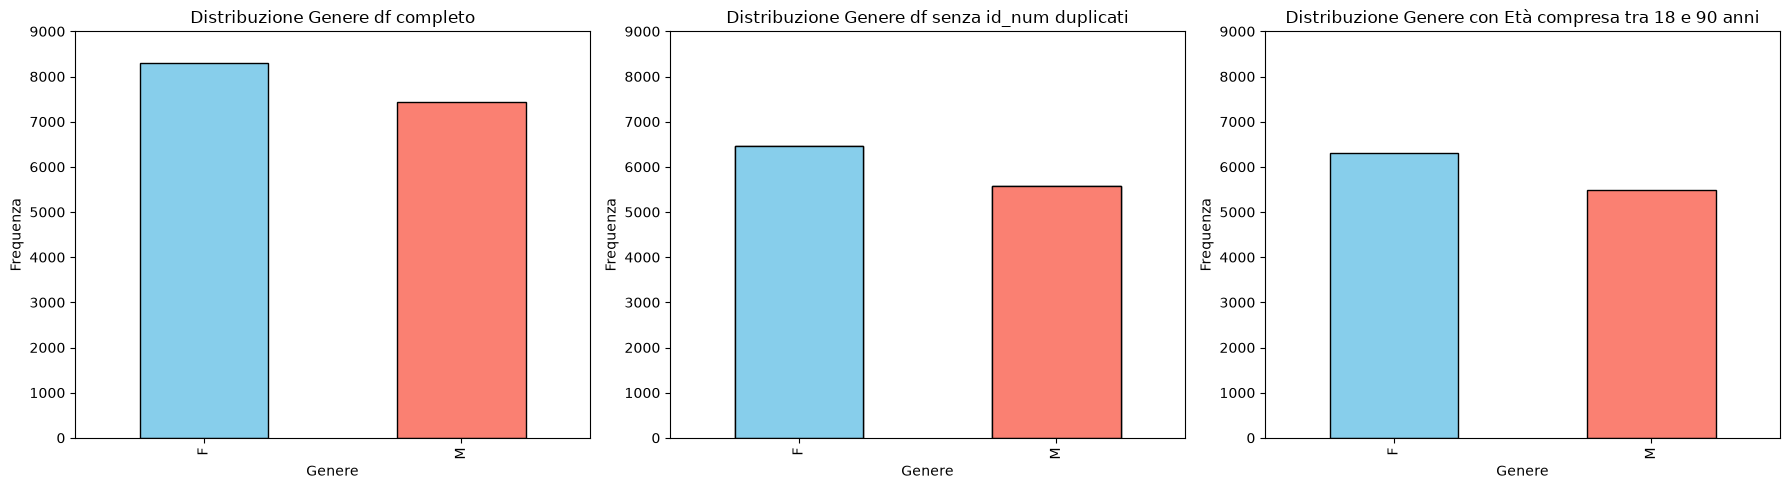

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

df['Genere'].value_counts().plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'], edgecolor='black')
axes[0].set_title('Distribuzione Genere df completo')
axes[0].set_xlabel('Genere')
axes[0].set_ylim(0, 9000)
axes[0].set_ylabel('Frequenza')

df_non_duplicate['Genere'].value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'], edgecolor='black')
axes[1].set_title('Distribuzione Genere df senza id_num duplicati')
axes[1].set_xlabel('Genere')
axes[1].set_ylim(0, 9000)
axes[1].set_ylabel('Frequenza')

df_non_duplicate['Genere'].value_counts().plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon'], edgecolor='black')
axes[1].set_title('Distribuzione Genere df senza id_num duplicati')
axes[1].set_xlabel('Genere')
axes[1].set_ylim(0, 9000)
axes[1].set_ylabel('Frequenza')

df_drop_eta['Genere'].value_counts().plot(kind='bar', ax=axes[2], color=['skyblue', 'salmon'], edgecolor='black')
axes[2].set_title('Distribuzione Genere con Età compresa tra 18 e 90 anni')
axes[2].set_xlabel('Genere')
axes[2].set_ylim(0, 9000)
axes[2].set_ylabel('Frequenza')

plt.tight_layout()
plt.show()

## Controllo distribuzione delle età

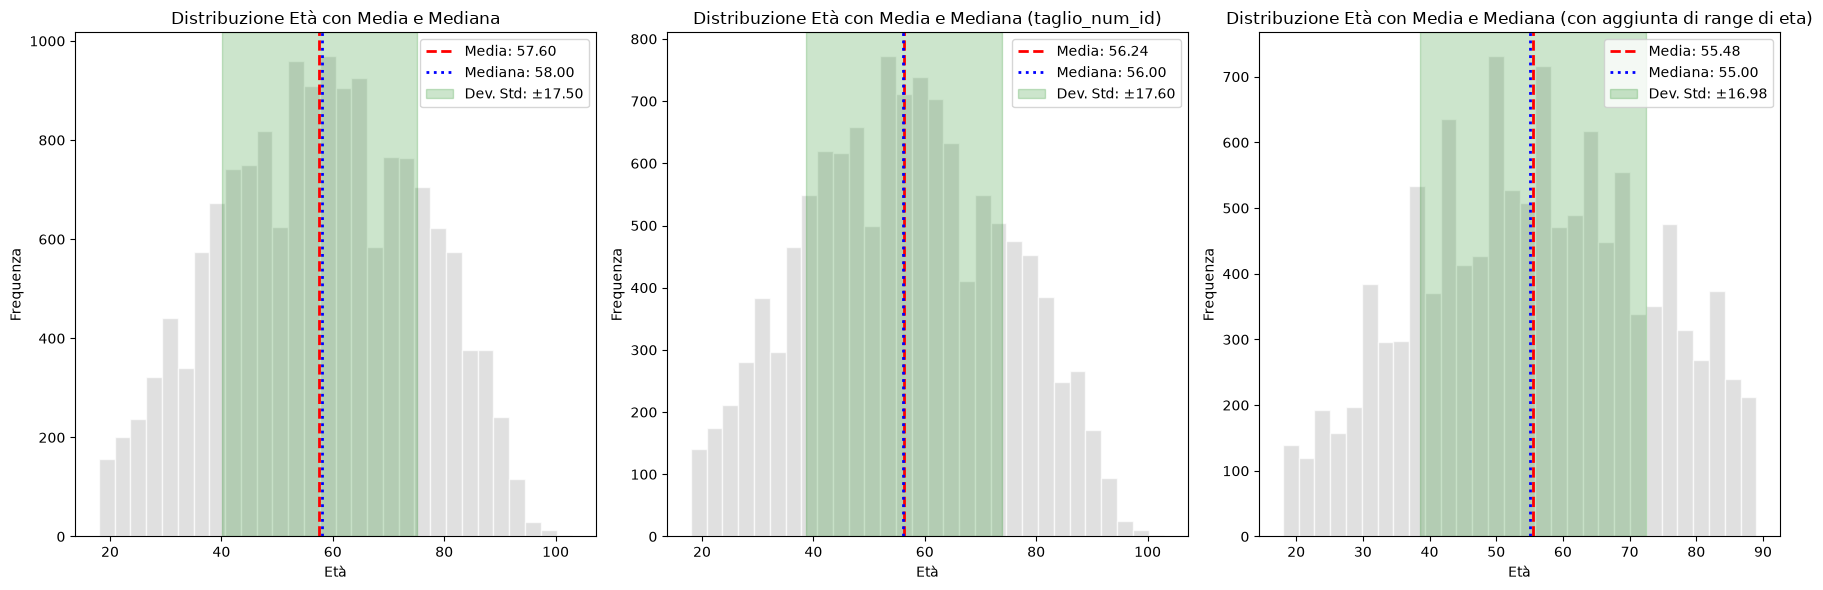

CON ID DUPLICATI media: 58anni, mediana: 58anni, dev_std: 18anni
SENZA ID DUPLICATI media: 56anni, mediana: 56anni, dev_std: 18anni
SENZA ID DUPLICATI E RANGE ETA media: 55anni, mediana: 55anni, dev_std: 17anni


In [21]:
media_df = df.Età.mean()
mediana_df = df.Età.median()
std_dev = df.Età.std()

media_df_pulito = df_non_duplicate.Età.mean()
mediana_df_pulito = df_non_duplicate.Età.median()
std_dev_pulito = df_non_duplicate.Età.std()

media_df_eta = df_drop_eta.Età.mean()
mediana_df_eta = df_drop_eta.Età.median()
std_dev_eta = df_drop_eta.Età.std()

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

axes[0].hist(df['Età'], bins=30, color='lightgray', edgecolor='white', alpha=0.7)
axes[0].axvline(media_df, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_df:.2f}')
axes[0].axvline(mediana_df, color='blue', linestyle='dotted', linewidth=2, label=f'Mediana: {mediana_df:.2f}')
axes[0].axvspan(media_df - std_dev, media_df + std_dev, color='green', alpha=0.2, label=f'Dev. Std: ±{std_dev:.2f}')
axes[0].set_title('Distribuzione Età con Media e Mediana')
axes[0].set_xlabel('Età')
axes[0].set_ylabel('Frequenza')
axes[0].legend()

axes[1].hist(df_non_duplicate['Età'], bins=30, color='lightgray', edgecolor='white', alpha=0.7)
axes[1].axvline(media_df_pulito, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_df_pulito:.2f}')
axes[1].axvline(mediana_df_pulito, color='blue', linestyle='dotted', linewidth=2, label=f'Mediana: {mediana_df_pulito:.2f}')
axes[1].axvspan(media_df_pulito - std_dev_pulito, media_df_pulito + std_dev_pulito, color='green', alpha=0.2, label=f'Dev. Std: ±{std_dev_pulito:.2f}')
axes[1].set_title('Distribuzione Età con Media e Mediana (taglio_num_id)')
axes[1].set_xlabel('Età')
axes[1].set_ylabel('Frequenza')
axes[1].legend()

axes[2].hist(df_drop_eta['Età'], bins=30, color='lightgray', edgecolor='white', alpha=0.7)
axes[2].axvline(media_df_eta, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_df_eta:.2f}')
axes[2].axvline(mediana_df_eta, color='blue', linestyle='dotted', linewidth=2, label=f'Mediana: {mediana_df_eta:.2f}')
axes[2].axvspan(media_df_eta - std_dev_eta, media_df_eta + std_dev_eta, color='green', alpha=0.2, label=f'Dev. Std: ±{std_dev_eta:.2f}')
axes[2].set_title('Distribuzione Età con Media e Mediana (con aggiunta di range di eta)')
axes[2].set_xlabel('Età')
axes[2].set_ylabel('Frequenza')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"CON ID DUPLICATI media: {media_df:.0f}anni, mediana: {mediana_df:.0f}anni, dev_std: {std_dev:.0f}anni")
print(f"SENZA ID DUPLICATI media: {media_df_pulito:.0f}anni, mediana: {mediana_df_pulito:.0f}anni, dev_std: {std_dev_pulito:.0f}anni")
print(f"SENZA ID DUPLICATI E RANGE ETA media: {media_df_eta:.0f}anni, mediana: {mediana_df_eta:.0f}anni, dev_std: {std_dev_eta:.0f}anni")

## Controllo delle date per trovare gli esami più vecchi a quando risalgono

Le date sono dei prelievi sono tra inizio 2021 fino al 16 maggio 2026

In [22]:
df["Data dell\'Episodio"].min()

Timestamp('2021-01-04 00:00:00')

In [23]:
df_non_duplicate["Data dell\'Episodio"].min()

Timestamp('2021-01-04 00:00:00')

In [24]:
df["Data dell\'Episodio"].max()

Timestamp('2026-05-16 00:00:00')

# Esplorazione parametri glicemici

**Glucosio**: Principale substrato energetico dell’organismo e rappresenta uno dei parametri fondamentali del metabolismo glucidico. La sua concentrazione nel sangue riflette l’equilibrio tra produzione epatica, assorbimento intestinale e utilizzo periferico mediato dall’insulina. Valori elevati possono indicare alterata regolazione glicemica, insulino-resistenza o diabete mellito. L’iperglicemia cronica è associata a stress ossidativo, glicazione proteica, infiammazione vascolare e accelerazione dell’invecchiamento metabolico. Nei modelli predittivi il glucosio è una delle feature più informative per descrivere lo stato metabolico generale.


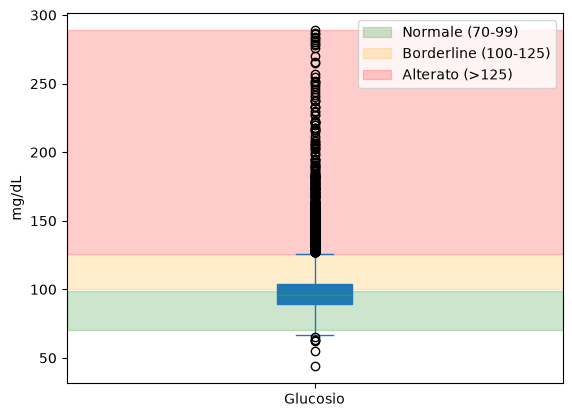

In [25]:
fig, ax = plt.subplots()

ax.axhspan(70, 99, color='green', alpha=0.2, label='Normale (70-99)')
ax.axhspan(100, 125, color='orange', alpha=0.2, label='Borderline (100-125)')
ax.axhspan(126, df_drop_eta["Glucosio"].max(), color='red', alpha=0.2, label='Alterato (>125)')

df_drop_eta["Glucosio"].plot.box(ax=ax, patch_artist=True)

ax.legend(loc="upper right")

ax.set_ylabel("mg/dL")
plt.show()   

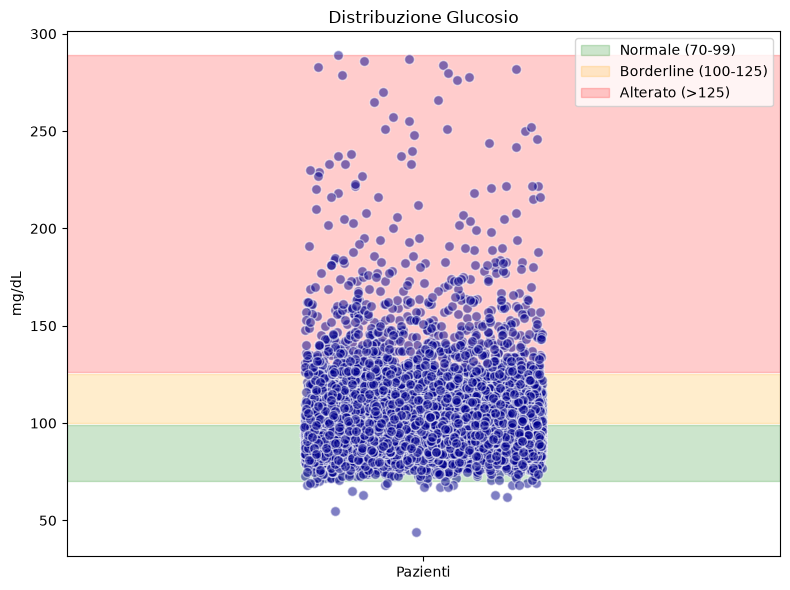

In [26]:
fig, ax = plt.subplots(figsize=(8, 6))

x_jitter = np.random.uniform(0.9, 1.1, size=len(df_drop_eta))

ax.scatter(x_jitter, df_drop_eta["Glucosio"], alpha=0.5, c='darkblue', edgecolors='white', s=50, zorder=3)

ax.axhspan(70, 99, color='green', alpha=0.2, label='Normale (70-99)')
ax.axhspan(100, 125, color='orange', alpha=0.2, label='Borderline (100-125)')
ax.axhspan(126, df_drop_eta["Glucosio"].max(), color='red', alpha=0.2, label='Alterato (>125)')

ax.set_title("Distribuzione Glucosio")
ax.set_ylabel("mg/dL")
ax.set_xticks([1])
ax.set_xticklabels(["Pazienti"])
ax.set_xlim(0.7, 1.3)

ax.legend(loc="upper right", frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

In [27]:
print(f"Glucosio - min: {df_drop_eta['Glucosio'].min()} mg/dL | max: {df_drop_eta['Glucosio'].max()} mg/dL")

Glucosio - min: 44 mg/dL | max: 289 mg/dL


In [28]:
print(f"n. Pazienti con Glucosio > 300: {len(df_drop_eta.query('Glucosio > 300'))}")
print(f"n. Pazienti con Glucosio < 70: {len(df_drop_eta.query('Glucosio < 70'))}")

n. Pazienti con Glucosio > 300: 0
n. Pazienti con Glucosio < 70: 20


In [29]:
df_drop_eta.Glucosio.describe().round(1)

count    11803.0
mean        99.4
std         18.2
min         44.0
25%         89.0
50%         96.0
75%        104.0
max        289.0
Name: Glucosio, dtype: float64

# Esplorazione parametri lipidici

**Trigliceridi**:Rappresentano la principale forma di deposito energetico lipidico dell’organismo e derivano sia dall’alimentazione sia dalla sintesi epatica. Elevati livelli plasmatici sono frequentemente associati a insulino-resistenza, steatosi epatica, obesità viscerale e sindrome metabolica. Oltre al loro significato lipidico, i trigliceridi riflettono spesso una condizione di disfunzione metabolica sistemica. Nei modelli predittivi vengono utilizzati sia come biomarcatori diretti sia nella costruzione di indici derivati, come TyG Index e rapporto TG/HDL.

**HDL Colesterolo**:Comunemente associato alla funzione protettiva cardiovascolare, perché partecipa al trasporto inverso del colesterolo, cioè al ritorno del colesterolo dai tessuti periferici verso il fegato: questa funzione contribuisce alla rimozione del colesterolo in eccesso e svolge un ruolo protettivo nei confronti dell’aterosclerosi. Livelli bassi di HDL si osservano frequentemente nella sindrome metabolica e nell’insulino-resistenza. In un modello di deep learning, HDL non va interpretato isolatamente, ma in relazione ad altri marcatori lipidici, come trigliceridi, LDL e colesterolo totale, perché il suo valore predittivo emerge soprattutto nei rapporti aterogeni.

**LDL Colesterolo**:Indica la quota di colesterolo trasportata dalle lipoproteine LDL, coinvolte nello sviluppo dell’aterosclerosi. Valori elevati favoriscono l’accumulo lipidico nella parete arteriosa e aumentano il rischio cardiovascolare. Tuttavia l’LDL-C misura il contenuto di colesterolo nelle particelle LDL, non necessariamente il numero delle particelle aterogene. In un progetto AI, LDL resta una feature importante, ma va integrata con marker più fini del rischio aterogeno.

**Colesterolo Totale**:Misura la concentrazione complessiva di colesterolo circolante nel sangue, includendo diverse frazioni lipoproteiche come HDL, LDL e VLDL. Da solo fornisce un’indicazione generale del metabolismo lipidico, ma risulta più informativo quando interpretato insieme alle singole componenti lipidiche. Valori elevati possono associarsi ad aumentato rischio cardiovascolare, soprattutto in presenza di HDL ridotto e trigliceridi elevati. In ambito AI e data analysis il colesterolo totale rappresenta spesso una variabile di base utile per costruire score lipidici compositi e valutazioni del rischio aterogeno.

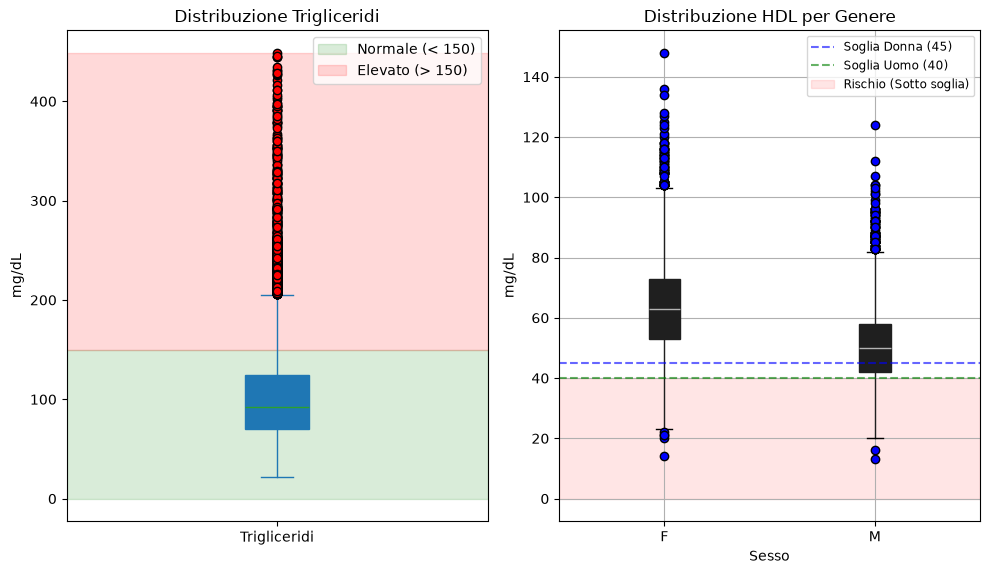

In [30]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 6))

ax1.axhspan(0, 150, color='green', alpha=0.15, label='Normale (< 150)')
ax1.axhspan(150, df_drop_eta["Trigliceridi"].max(), color='red', alpha=0.15, label='Elevato (> 150)')

df_drop_eta["Trigliceridi"].plot.box(ax=ax1, patch_artist=True, flierprops=dict(markerfacecolor='red', marker='o'))
ax1.set_title("Distribuzione Trigliceridi")
ax1.set_ylabel("mg/dL")
ax1.legend(loc="upper right")

df_drop_eta.boxplot(column="Colesterolo HDL", by="Genere", ax=ax2, patch_artist=True, flierprops=dict(markerfacecolor='blue', marker='o'))

ax2.axhline(y=45, color='blue', linestyle='--', alpha=0.6, label='Soglia Donna (45)')
ax2.axhline(y=40, color='green', linestyle='--', alpha=0.6, label='Soglia Uomo (40)')

ax2.axhspan(0, 40, color='red', alpha=0.1, label='Rischio (Sotto soglia)')

ax2.set_title("Distribuzione HDL per Genere")
ax2.set_ylabel("mg/dL")
ax2.set_xlabel("Sesso")
plt.suptitle("")

ax2.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

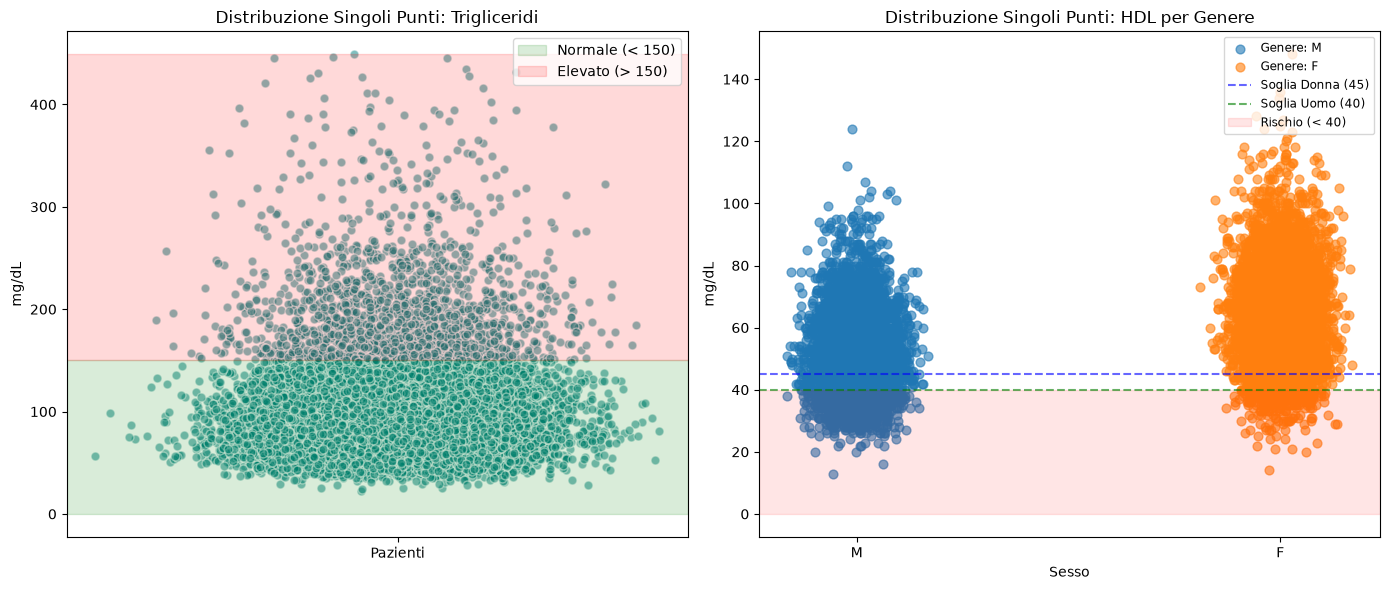

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_jitter_trig = np.random.normal(1, 0.04, size=len(df_drop_eta))

ax1.scatter(x_jitter_trig, df_drop_eta["Trigliceridi"], alpha=0.5, c='teal', edgecolors='w', s=40)

ax1.axhspan(0, 150, color='green', alpha=0.15, label='Normale (< 150)')
ax1.axhspan(150, df_drop_eta["Trigliceridi"].max(), color='red', alpha=0.15, label='Elevato (> 150)')

ax1.set_title("Distribuzione Singoli Punti: Trigliceridi")
ax1.set_ylabel("mg/dL")
ax1.set_xticks([1])
ax1.set_xticklabels(["Pazienti"])
ax1.legend(loc="upper right")

generi = df_drop_eta["Genere"].unique()
colori = {'M': 'blue', 'F': 'pink'}

for i, genere in enumerate(generi, start=1):
    subset = df_drop_eta[df_drop_eta["Genere"] == genere]
    x_jitter_hdl = np.random.normal(i, 0.05, size=len(subset))
    ax2.scatter(x_jitter_hdl, subset["Colesterolo HDL"], alpha=0.6, label=f"Genere: {genere}", s=40)

ax2.axhline(y=45, color='blue', linestyle='--', alpha=0.6, label='Soglia Donna (45)')
ax2.axhline(y=40, color='green', linestyle='--', alpha=0.6, label='Soglia Uomo (40)')
ax2.axhspan(0, 40, color='red', alpha=0.1, label='Rischio (< 40)')

ax2.set_title("Distribuzione Singoli Punti: HDL per Genere")
ax2.set_ylabel("mg/dL")
ax2.set_xlabel("Sesso")
ax2.set_xticks(range(1, len(generi) + 1))
ax2.set_xticklabels(generi)
ax2.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

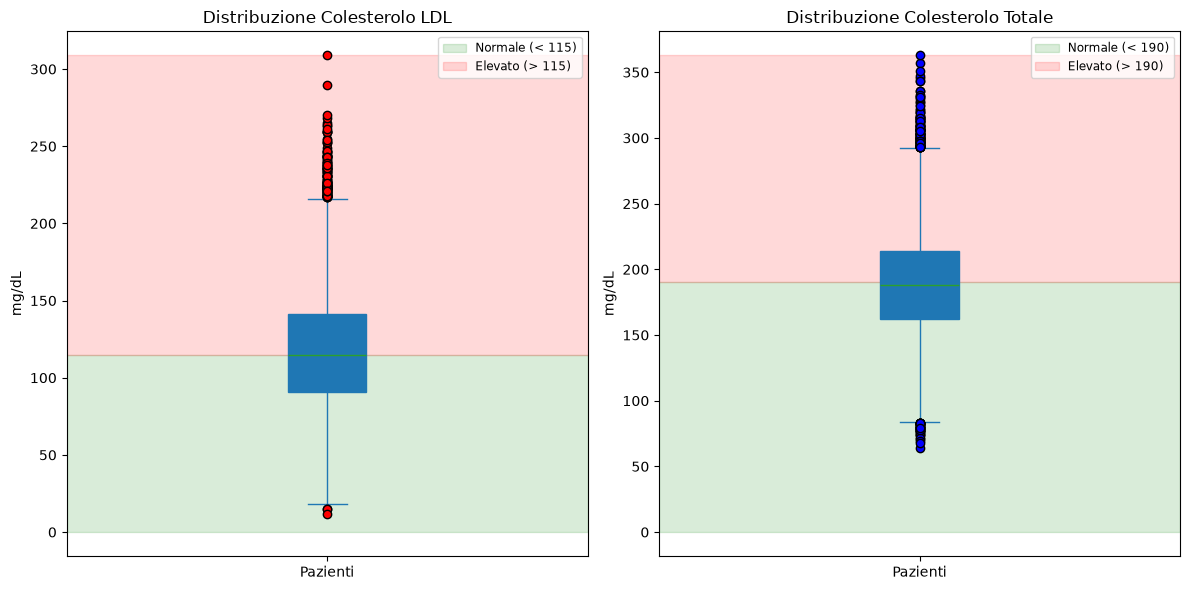

In [32]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.axhspan(0, 115, color='green', alpha=0.15, label='Normale (< 115)')
ax1.axhspan(115, df["Colesterolo LDL"].max(), color='red', alpha=0.15, label='Elevato (> 115)')

df["Colesterolo LDL"].plot.box(ax=ax1, patch_artist=True, flierprops=dict(markerfacecolor='red', marker='o'))

ax1.set_title("Distribuzione Colesterolo LDL")
ax1.set_ylabel("mg/dL")
ax1.set_xticklabels(["Pazienti"])
ax1.legend(loc="upper right", fontsize='small')

ax2.axhspan(0, 190, color='green', alpha=0.15, label='Normale (< 190)')
ax2.axhspan(190, df["Colesterolo totale"].max(), color='red', alpha=0.15, label='Elevato (> 190)')

df["Colesterolo totale"].plot.box(ax=ax2, patch_artist=True, flierprops=dict(markerfacecolor='blue', marker='o'))

ax2.set_title("Distribuzione Colesterolo Totale")
ax2.set_ylabel("mg/dL")
ax2.set_xticklabels(["Pazienti"])
ax2.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

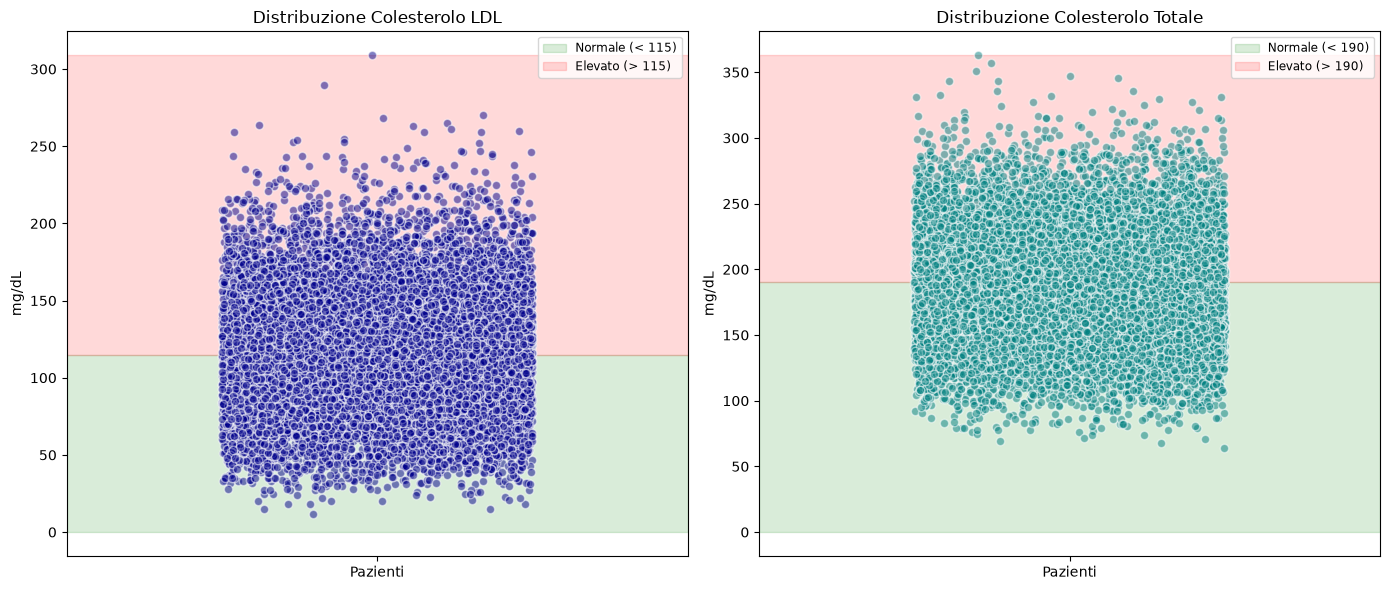

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x_jitter_ldl = np.random.uniform(0.85, 1.15, size=len(df))

ax1.axhspan(0, 115, color='green', alpha=0.15, label='Normale (< 115)')
ax1.axhspan(115, df["Colesterolo LDL"].max(), color='red', alpha=0.15, label='Elevato (> 115)')

ax1.scatter(x_jitter_ldl, df["Colesterolo LDL"], alpha=0.5, c='darkblue', edgecolors='white', zorder=3)

ax1.set_title("Distribuzione Colesterolo LDL")
ax1.set_ylabel("mg/dL")
ax1.set_xticks([1])
ax1.set_xticklabels(["Pazienti"])
ax1.set_xlim(0.7, 1.3)
ax1.legend(loc="upper right", fontsize='small')

x_jitter_tot = np.random.uniform(0.85, 1.15, size=len(df))

ax2.axhspan(0, 190, color='green', alpha=0.15, label='Normale (< 190)')
ax2.axhspan(190, df["Colesterolo totale"].max(), color='red', alpha=0.15, label='Elevato (> 190)')

ax2.scatter(x_jitter_tot, df["Colesterolo totale"], alpha=0.5, c='teal', edgecolors='white', zorder=3)

ax2.set_title("Distribuzione Colesterolo Totale")
ax2.set_ylabel("mg/dL")
ax2.set_xticks([1])
ax2.set_xticklabels(["Pazienti"])
ax2.set_xlim(0.7, 1.3)
ax2.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

In [34]:
print(f"Trigliceridi - min: {df['Trigliceridi'].min()} mg/dL | max: {df['Trigliceridi'].max()} mg/dL")
print(f"HDL - min: {df['Colesterolo HDL'].min()} mg/dL | max: {df['Colesterolo HDL'].max()} mg/dL")
print(f"LDL - min: {df['Colesterolo LDL'].min()} mg/dL | max: {df['Colesterolo LDL'].max()} mg/dL")
print(f"Totale - min: {df['Colesterolo totale'].min()} mg/dL | max: {df['Colesterolo totale'].max()} mg/dL")

Trigliceridi - min: 19 mg/dL | max: 449 mg/dL
HDL - min: 13 mg/dL | max: 148 mg/dL
LDL - min: 12 mg/dL | max: 309 mg/dL
Totale - min: 64 mg/dL | max: 363 mg/dL


In [35]:
df_drop_eta.Trigliceridi.describe().round(1)

count    11803.0
mean       104.4
std         51.6
min         22.0
25%         70.0
50%         92.0
75%        124.0
max        449.0
Name: Trigliceridi, dtype: float64

In [36]:
df_drop_eta["Colesterolo HDL"].describe().round(1)

count    11803.0
mean        57.9
std         15.2
min         13.0
25%         47.0
50%         56.0
75%         67.0
max        148.0
Name: Colesterolo HDL, dtype: float64

In [37]:
df_drop_eta["Colesterolo LDL"].describe().round(1)

count    11803.0
mean       116.9
std         37.0
min         12.0
25%         91.0
50%        115.0
75%        141.0
max        290.0
Name: Colesterolo LDL, dtype: float64

In [38]:
df_drop_eta["Colesterolo totale"].describe().round(1)

count    11803.0
mean       189.3
std         39.8
min         74.0
25%        162.0
50%        189.0
75%        214.0
max        363.0
Name: Colesterolo totale, dtype: float64

## Esplorazione parametri emocromo

**Neutrofili (valore assoluto)**: Sono le principali cellule dell’immunità innata e rappresentano la prima linea di difesa contro infezioni e processi infiammatori acuti. Un aumento persistente dei neutrofili può riflettere uno stato di infiammazione cronica di basso grado, frequentemente associato a obesità, sindrome metabolica e malattie cardiovascolari. In ambito di aging biologico i neutrofili sono particolarmente rilevanti perché contribuiscono alla definizione di indici infiammatori compositi come NLR e SII, utilizzati per stimare il burden infiammatorio sistemico.

**Linfociti (valore assoluto)**: Cellule fondamentali dell’immunità adattativa e partecipano alla risposta immunitaria specifica contro agenti patogeni e cellule alterate. La loro concentrazione può ridursi in presenza di stress biologico cronico, infiammazione sistemica o alterazioni dell’equilibrio immunitario. Nei modelli clinici e computazionali i linfociti assumono particolare importanza quando vengono utilizzati in rapporti con altre cellule ematiche, come neutrofili e piastrine. Questi rapporti possono fornire informazioni indirette sullo stato infiammatorio cronico e sui processi di inflammaging.

**Piastrine (PLT)**: Sono frammenti cellulari coinvolti principalmente nei processi di coagulazione, ma svolgono anche un ruolo importante nell’infiammazione e nella risposta immunitaria. Alterazioni della conta piastrinica possono essere associate a flogosi cronica, malattie cardiovascolari o danno epatico avanzato. In ambito epatologico una riduzione delle piastrine può rappresentare un segnale indiretto di fibrosi o ipertensione portale. Le piastrine sono inoltre utilizzate in numerosi indici clinici compositi, come FIB-4, PLR e SII.

**RDW-CV (Red Cell Distribution Width)**: Misura la variabilità dimensionale dei globuli rossi circolanti. Valori elevati indicano una maggiore eterogeneità delle dimensioni eritrocitarie e possono riflettere alterazioni dell’eritropoiesi, infiammazione cronica, stress ossidativo o disordine metabolico sistemico. Negli ultimi anni RDW è emerso come marker prognostico in numerose condizioni cliniche, incluse malattie cardiovascolari, insufficienza renale, fragilità e mortalità generale. Dal punto di vista biologico viene considerato un indicatore aspecifico di perdita dell’omeostasi fisiologica e di vulnerabilità sistemica associata all’invecchiamento.

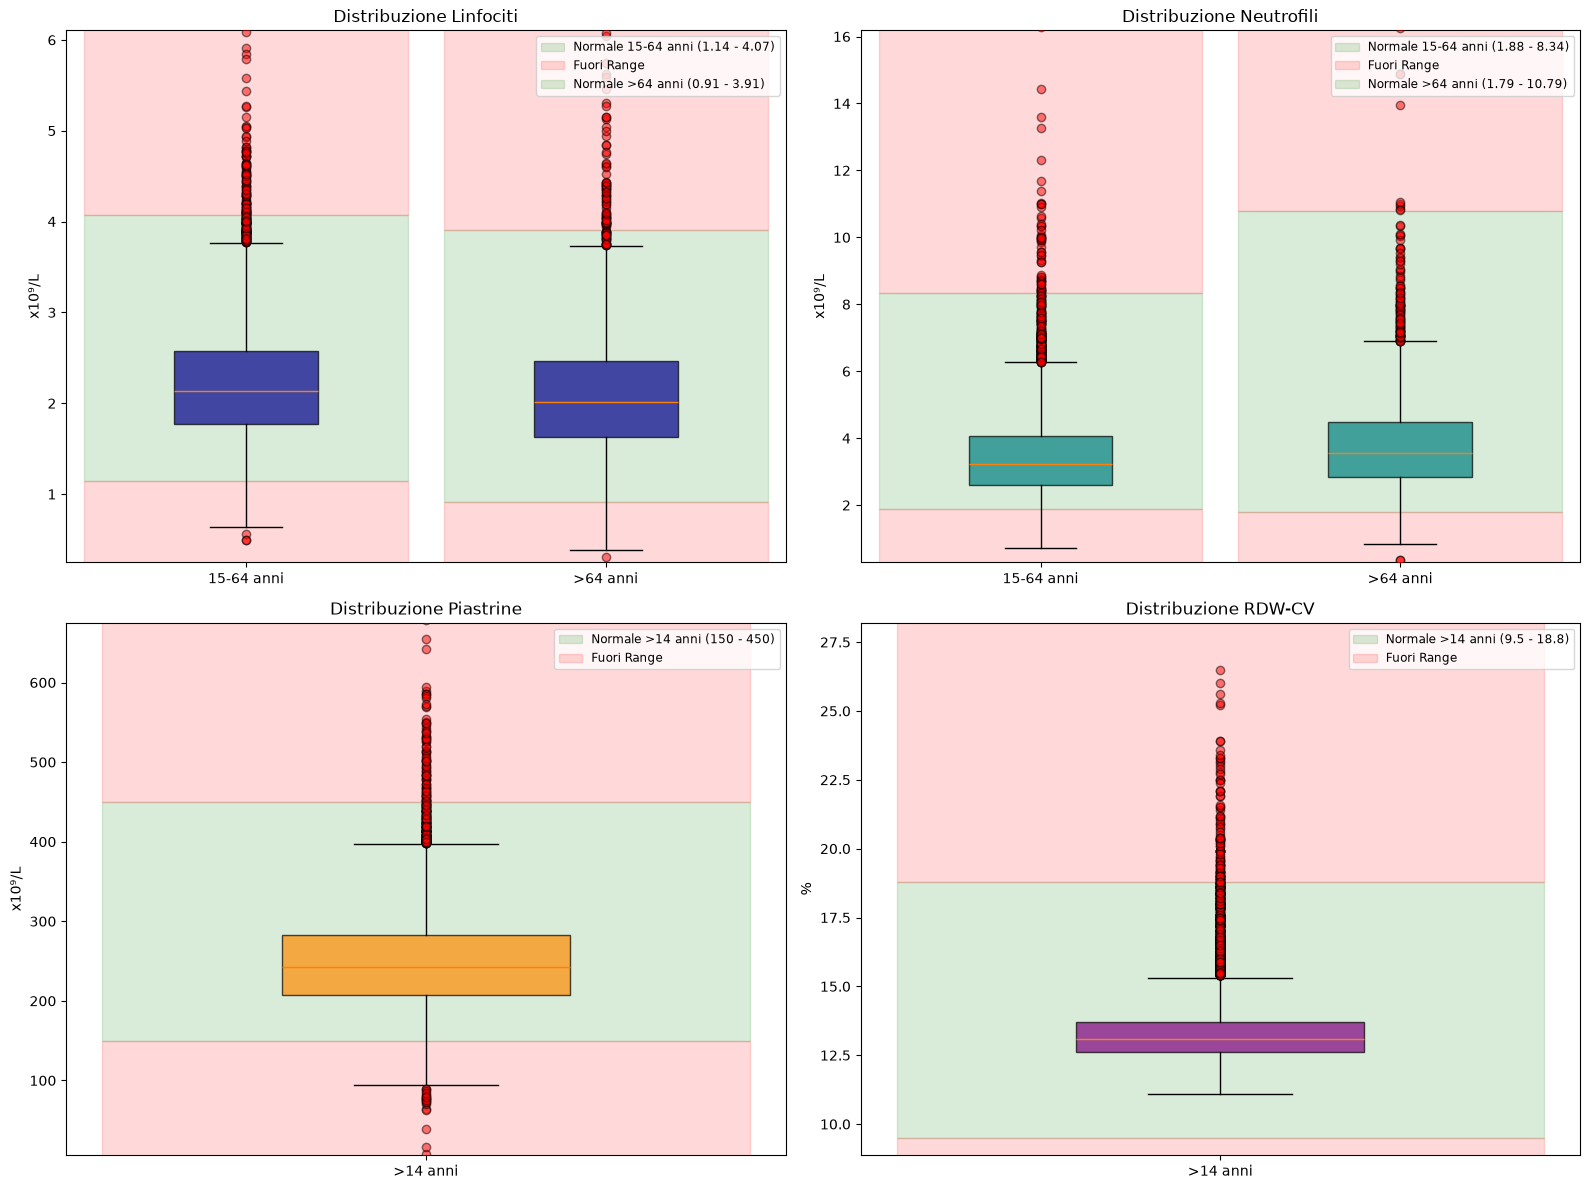

In [39]:
limiti = {
    'Neutrofili': {'15-64 anni': (1.88, 8.34), '>64 anni': (1.79, 10.79)},
    'Linfociti': {'15-64 anni': (1.14, 4.07), '>64 anni': (0.91, 3.91)},
    'Piastrine': {'>14 anni': (150, 450)},
    'RDW-CV': {'>14 anni': (9.5, 18.8)}
}

parametri = ['Linfociti', 'Neutrofili', 'Piastrine', 'RDW-CV']
colori_plot = ['darkblue', 'teal', 'darkorange', 'purple']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, param, color in zip(axes.flatten(), parametri, colori_plot):
    
    if param in ['Linfociti', 'Neutrofili']:
        df_drop_eta['Gruppo_Età'] = np.where(df_drop_eta['Età'] <= 64, '15-64 anni', '>64 anni')
        order = ['15-64 anni', '>64 anni']
    else:
        df_drop_eta['Gruppo_Età'] = '>14 anni'
        order = ['>14 anni']
        
    data_to_plot = [df_drop_eta[df_drop_eta['Gruppo_Età'] == cat][param].dropna() for cat in order]
    
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti[param].values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[param][cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} ({vmin} - {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, -100, vmin, color='red', alpha=0.15, label=lbl_r, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, zorder=0) # Moltiplicato x10 per coprire tutto lo sfondo
            
    bp = ax.boxplot(data_to_plot, positions=np.arange(1, len(order) + 1), widths=0.4, patch_artist=True, zorder=3)
    
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.7)
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor='red', alpha=0.5)
            
    ax.set_title(f"Distribuzione {param}")
    ax.set_ylabel("%" if param == "RDW-CV" else "x10⁹/L")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

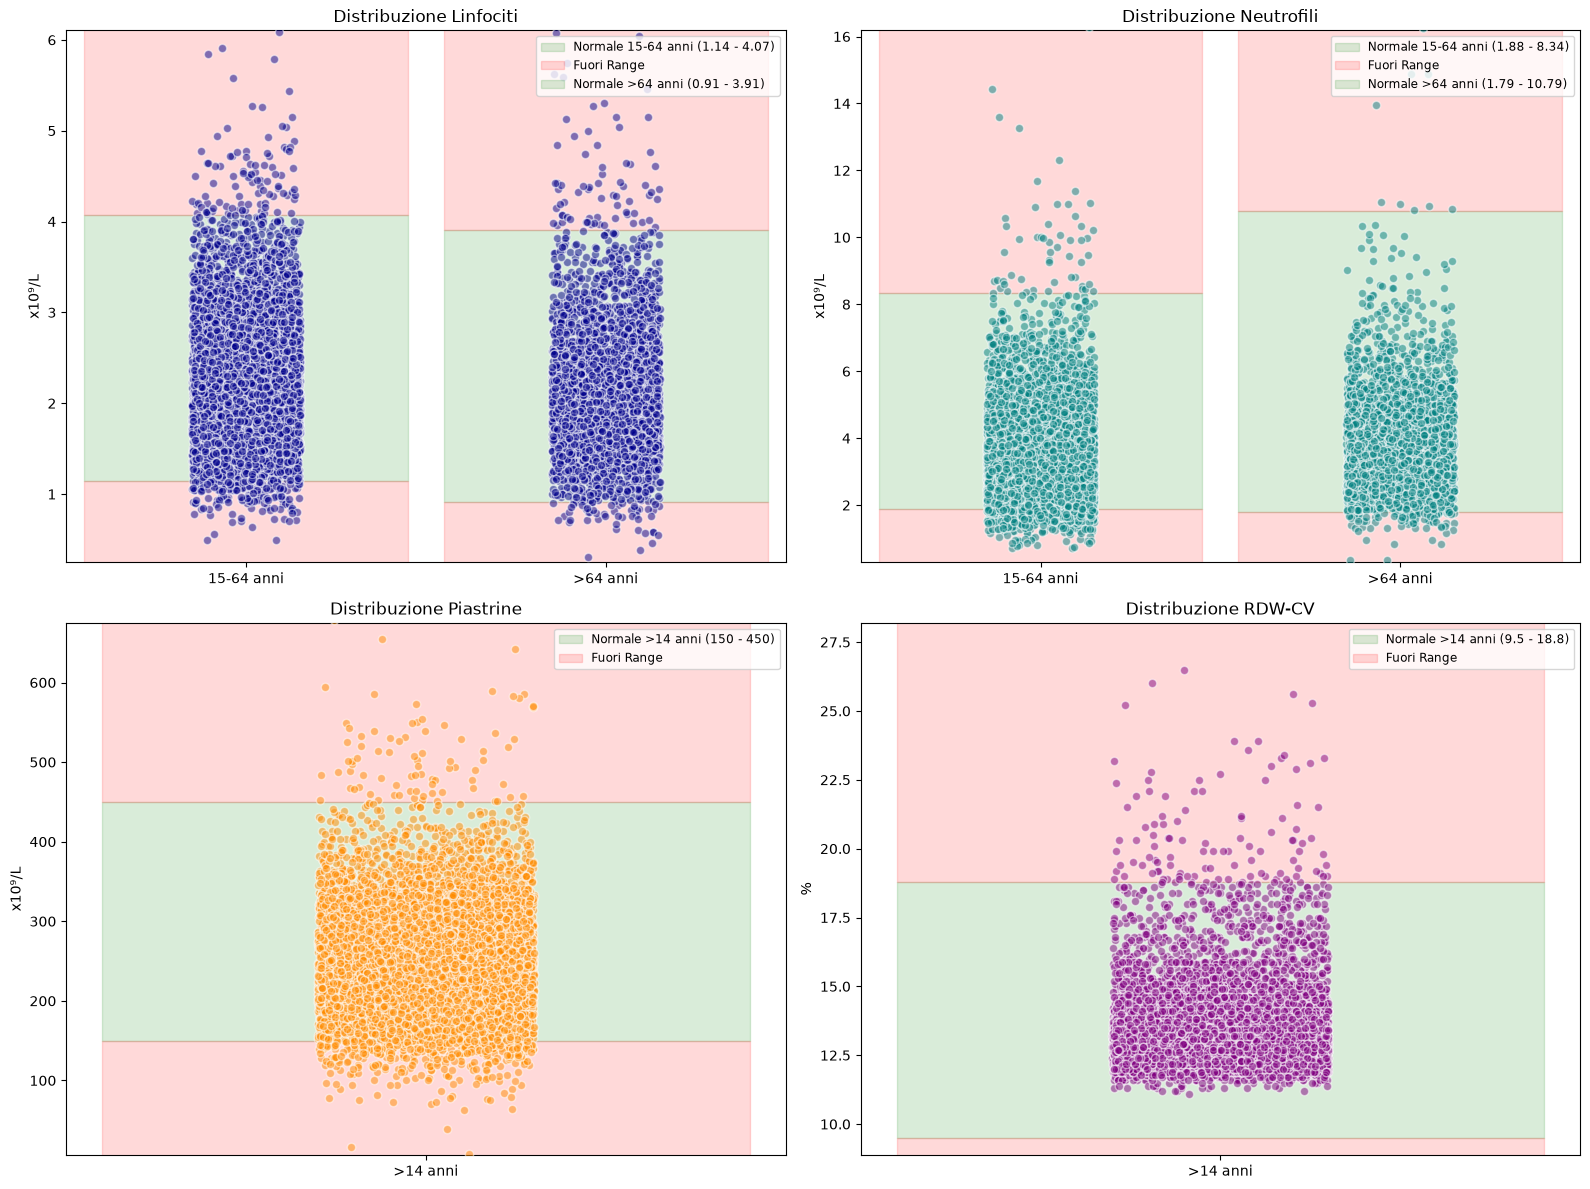

In [40]:
limiti = {
    'Neutrofili': {'15-64 anni': (1.88, 8.34), '>64 anni': (1.79, 10.79)},
    'Linfociti': {'15-64 anni': (1.14, 4.07), '>64 anni': (0.91, 3.91)},
    'Piastrine': {'>14 anni': (150, 450)},
    'RDW-CV': {'>14 anni': (9.5, 18.8)}
}

parametri = ['Linfociti', 'Neutrofili', 'Piastrine', 'RDW-CV']
colori_plot = ['darkblue', 'teal', 'darkorange', 'purple']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, param, color in zip(axes.flatten(), parametri, colori_plot):
    
    if param in ['Linfociti', 'Neutrofili']:
        df_drop_eta['Gruppo_Età'] = np.where(df_drop_eta['Età'] <= 64, '15-64 anni', '>64 anni')
        order = ['15-64 anni', '>64 anni']
    else:
        df_drop_eta['Gruppo_Età'] = '>14 anni'
        order = ['>14 anni']
        
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti[param].values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[param][cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} ({vmin} - {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, -100, vmin, color='red', alpha=0.15, label=lbl_r, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, zorder=0)

        subset = df_drop_eta[df_drop_eta['Gruppo_Età'] == cat][param].dropna()
        x_jitter = np.random.uniform(i + 0.85, i + 1.15, size=len(subset))
        ax.scatter(x_jitter, subset, alpha=0.5, c=color, edgecolors='white', zorder=3)

    ax.set_title(f"Distribuzione {param}")
    ax.set_ylabel("%" if param == "RDW-CV" else "x10⁹/L")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

In [41]:
print(f"Neutrofili - min: {df_drop_eta['Neutrofili'].min()} x10⁹/L | max: {df_drop_eta['Neutrofili'].max()} x10⁹/L")
print(f"Linfociti - min: {df_drop_eta['Linfociti'].min()} x10⁹/L | max: {df_drop_eta['Linfociti'].max()} x10⁹/L")
print(f"Piastrine - min: {df_drop_eta['Piastrine'].min()} x10⁹/L | max: {df_drop_eta['Piastrine'].max()} x10⁹/L")
print(f"RDW-CV - min: {df_drop_eta['RDW-CV'].min()} % | max: {df_drop_eta['RDW-CV'].max()} %")

Neutrofili - min: 0.36 x10⁹/L | max: 20.69 x10⁹/L
Linfociti - min: 0.31 x10⁹/L | max: 8.38 x10⁹/L
Piastrine - min: 8 x10⁹/L | max: 757 x10⁹/L
RDW-CV - min: 11.1 % | max: 26.5 %


In [42]:
df_drop_eta.Linfociti.describe().round(1)

count    11803.0
mean         2.2
std          0.7
min          0.3
25%          1.7
50%          2.1
75%          2.5
max          8.4
Name: Linfociti, dtype: float64

In [43]:
df_drop_eta.Neutrofili.describe().round(1)

count    11803.0
mean         3.6
std          1.4
min          0.4
25%          2.7
50%          3.3
75%          4.2
max         20.7
Name: Neutrofili, dtype: float64

In [44]:
df_drop_eta.Piastrine.describe().round(1)

count    11803.0
mean       248.1
std         62.2
min          8.0
25%        207.0
50%        242.0
75%        283.0
max        757.0
Name: Piastrine, dtype: float64

In [45]:
df_drop_eta["RDW-CV"].describe().round(1)

count    11803.0
mean        13.4
std          1.3
min         11.1
25%         12.6
50%         13.1
75%         13.7
max         26.5
Name: RDW-CV, dtype: float64

## Esplorazione parametri Epatici

**AST (GOT)**: Aspartato aminotransferasi — Enzima localizzato nel fegato ma anche in muscolo, cuore e altri tessuti. Un aumento può riflettere danno cellulare epatico o extraepatico. Per questo motivo è meno specifico di ALT per il danno epatico isolato. Il rapporto AST/ALT, noto anche come rapporto di De Ritis, viene frequentemente utilizzato per distinguere differenti pattern di danno epatico e per identificare condizioni metaboliche o fibrotiche più avanzate. In ambito computazionale AST è una variabile utile perché integra informazioni metaboliche, epatiche e sistemiche.

**ALT (GPT)**: Alanina aminotransferasi - Enzima presente principalmente negli epatociti e utilizzato come marker di danno epatico. Valori elevati possono indicare steatosi epatica, infiammazione cronica del fegato o danno metabolico epatico, così come nella steatosi epatica associata a disfunzione metabolica (MASLD), nelle epatiti e in altre condizioni di sofferenza epatica cronica. ALT è particolarmente interessante nei modelli di aging metabolico perché il fegato rappresenta uno dei principali organi coinvolti nel metabolismo glucidico e lipidico, e alterazioni persistenti possono riflettere disfunzione metabolica sistemica.

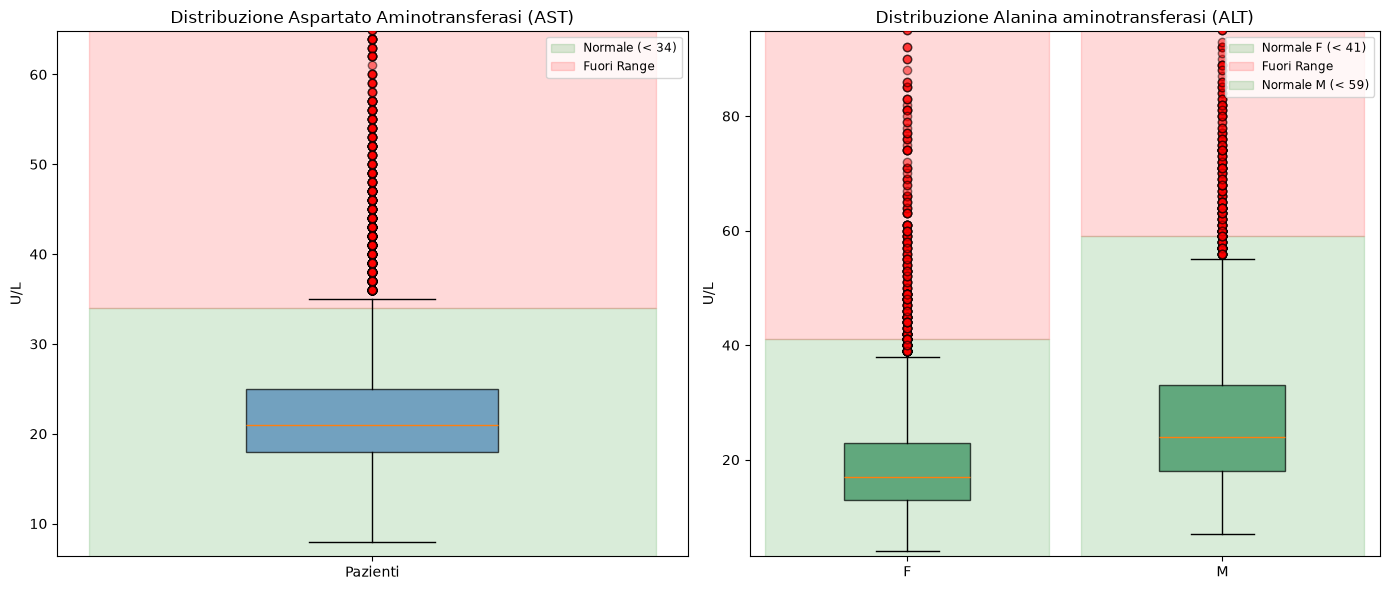

In [46]:
parametri = ['Aspartato Aminotransferasi (AST)', 'Alanina aminotransferasi (ALT)']
colori_plot = ['steelblue', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, param, color in zip(axes, parametri, colori_plot):
    
    if param == 'Aspartato Aminotransferasi (AST)':
        df_drop_eta['Gruppo'] = 'Pazienti'
        order = ['Pazienti']
        limiti = {'Pazienti': (0, 34)}
    else:
        df_drop_eta['Gruppo'] = df_drop_eta['Genere']
        order = ['F', 'M']
        order = [cat for cat in order if cat in df_drop_eta['Gruppo'].unique()]
        limiti = {'F': (0, 41), 'M': (0, 59)}
        
    data_to_plot = [df_drop_eta[df_drop_eta['Gruppo'] == cat][param].dropna() for cat in order]
    
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti.values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} (< {vmax})" if cat != 'Pazienti' else f"Normale (< {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, label=lbl_r, zorder=0)
            
    bp = ax.boxplot(data_to_plot, positions=np.arange(1, len(order) + 1), widths=0.4, patch_artist=True, zorder=3)
    
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.7)
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor='red', alpha=0.5)
            
    ax.set_title(f"Distribuzione {param}")
    ax.set_ylabel("U/L")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

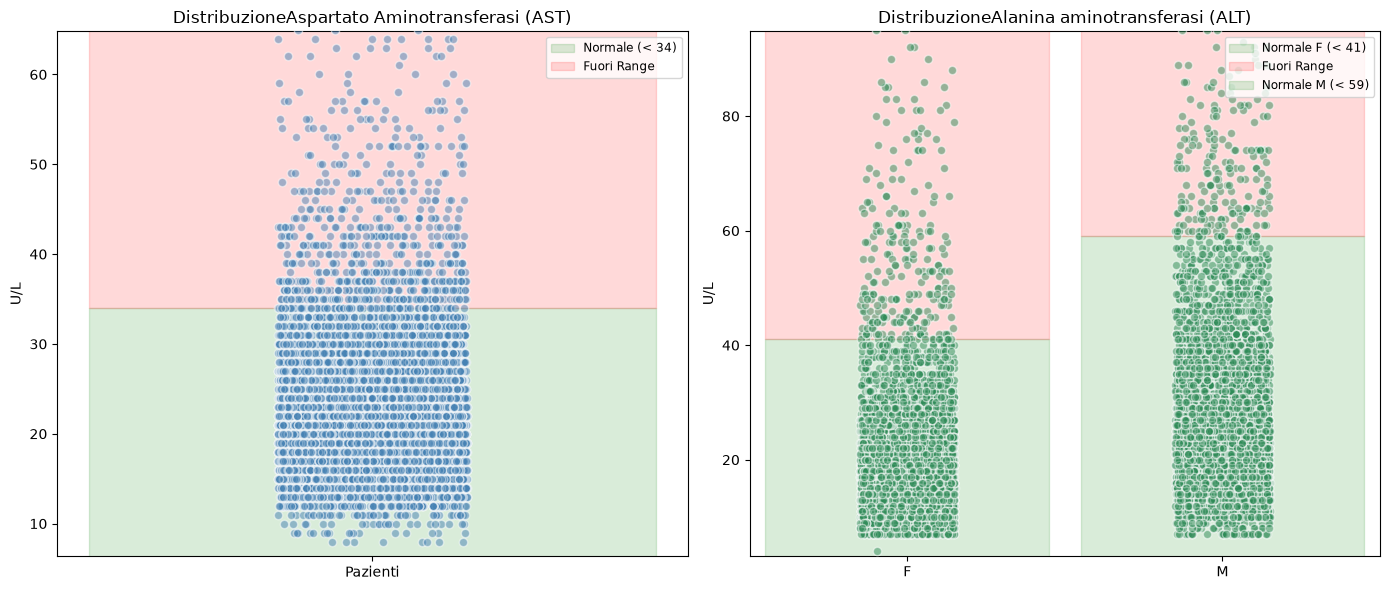

In [47]:
parametri = ['Aspartato Aminotransferasi (AST)', 'Alanina aminotransferasi (ALT)']
colori_plot = ['steelblue', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, param, color in zip(axes, parametri, colori_plot):
    
    if param == 'Aspartato Aminotransferasi (AST)':
        df_drop_eta['Gruppo'] = 'Pazienti'
        order = ['Pazienti']
        limiti = {'Pazienti': (0, 34)}
    else:
        df_drop_eta['Gruppo'] = df_drop_eta['Genere']
        order = ['F', 'M']
        order = [cat for cat in order if cat in df_drop_eta['Gruppo'].unique()]
        limiti = {'F': (0, 41), 'M': (0, 59)}
        
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti.values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} (< {vmax})" if cat != 'Pazienti' else f"Normale (< {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, label=lbl_r, zorder=0)

        subset = df_drop_eta[df_drop_eta['Gruppo'] == cat][param].dropna()
        x_jitter = np.random.uniform(i + 0.85, i + 1.15, size=len(subset))
        ax.scatter(x_jitter, subset, alpha=0.5, c=color, edgecolors='white', zorder=3)

    ax.set_title(f"Distribuzione{param}")
    ax.set_ylabel("U/L")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

In [48]:
print(f"ALT - min: {df_drop_eta['Alanina aminotransferasi (ALT)'].min()} U/L | max: {df_drop_eta['Alanina aminotransferasi (ALT)'].max()} U/L")
print(f"AST - min: {df_drop_eta['Aspartato Aminotransferasi (AST)'].min()} U/L | max: {df_drop_eta['Aspartato Aminotransferasi (AST)'].max()} U/L")

ALT - min: 4 U/L | max: 169 U/L
AST - min: 8 U/L | max: 101 U/L


In [49]:
df_drop_eta["Alanina aminotransferasi (ALT)"].describe().round(1)

count    11803.0
mean        23.6
std         14.0
min          4.0
25%         15.0
50%         20.0
75%         28.0
max        169.0
Name: Alanina aminotransferasi (ALT), dtype: float64

In [50]:
df_drop_eta["Aspartato Aminotransferasi (AST)"].describe().round(1)

count    11803.0
mean        22.6
std          8.0
min          8.0
25%         18.0
50%         21.0
75%         25.0
max        101.0
Name: Aspartato Aminotransferasi (AST), dtype: float64

## Esplorazione Marcatori Metabolici

**Creatinina sierica**: Prodotto del metabolismo muscolare derivato dalla degradazione della creatina fosfato. Viene eliminata quasi esclusivamente dal rene e per questo rappresenta uno dei principali marker utilizzati per stimare la funzione renale. Un aumento persistente può indicare riduzione del filtrato glomerulare o compromissione della capacità di eliminazione renale. Tuttavia il suo valore dipende anche da età, sesso e massa muscolare. Dal punto di vista dell’invecchiamento biologico la funzione renale è un indicatore importante della salute sistemica, poiché il deterioramento metabolico e cardiovascolare cronico può influenzare progressivamente la capacità filtrativa del rene.

**Urea**: Prodotto finale del metabolismo delle proteine e sintetizzata dal fegato per eliminare l’azoto derivante dal catabolismo aminoacidico. Viene successivamente eliminata dal rene attraverso la filtrazione glomerulare. Le sue concentrazioni plasmatiche dipendono da funzione renale, stato di idratazione, apporto proteico e livello di catabolismo metabolico. Valori alterati possono indicare compromissione renale, disidratazione o aumentato turnover proteico. In un modello di aging sistemico l’urea contribuisce alla valutazione dello stato metabolico e della funzionalità renale globale.

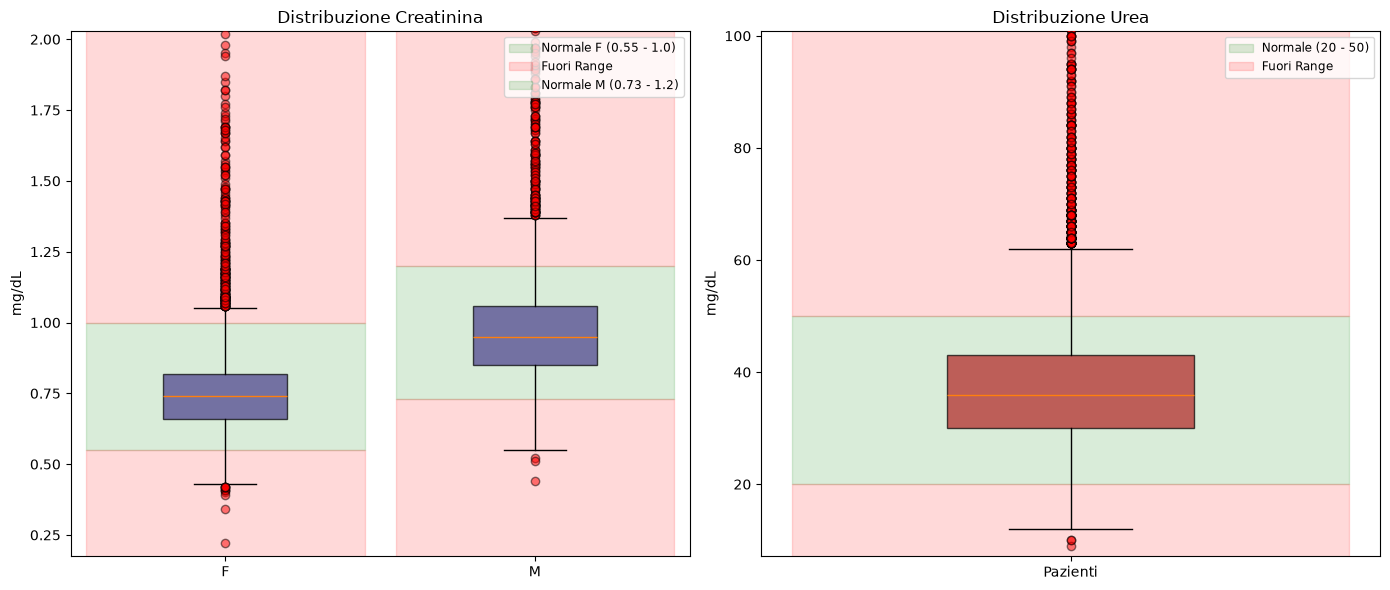

In [51]:
parametri = ['Creatinina', 'Urea']
colori_plot = ['darkslateblue', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, param, color in zip(axes, parametri, colori_plot):
    
    if param == 'Creatinina':
        df_drop_eta['Gruppo'] = df_drop_eta['Genere']
        order = ['F', 'M']
        order = [cat for cat in order if cat in df_drop_eta['Gruppo'].unique()]
        limiti = {'F': (0.55, 1.0), 'M': (0.73, 1.2)}
    else:
        df_drop_eta['Gruppo'] = 'Pazienti'
        order = ['Pazienti']
        limiti = {'Pazienti': (20, 50)}
        
    data_to_plot = [df_drop_eta[df_drop_eta['Gruppo'] == cat][param].dropna() for cat in order]
    
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti.values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} ({vmin} - {vmax})" if cat != 'Pazienti' else f"Normale ({vmin} - {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, -100, vmin, color='red', alpha=0.15, label=lbl_r, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, zorder=0)
            
    bp = ax.boxplot(data_to_plot, positions=np.arange(1, len(order) + 1), widths=0.4, patch_artist=True, zorder=3)
    
    for box in bp['boxes']:
        box.set_facecolor(color)
        box.set_alpha(0.7)
    for flier in bp['fliers']:
        flier.set(marker='o', markerfacecolor='red', alpha=0.5)
            
    ax.set_title(f"Distribuzione {param}")
    ax.set_ylabel("mg/dL")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

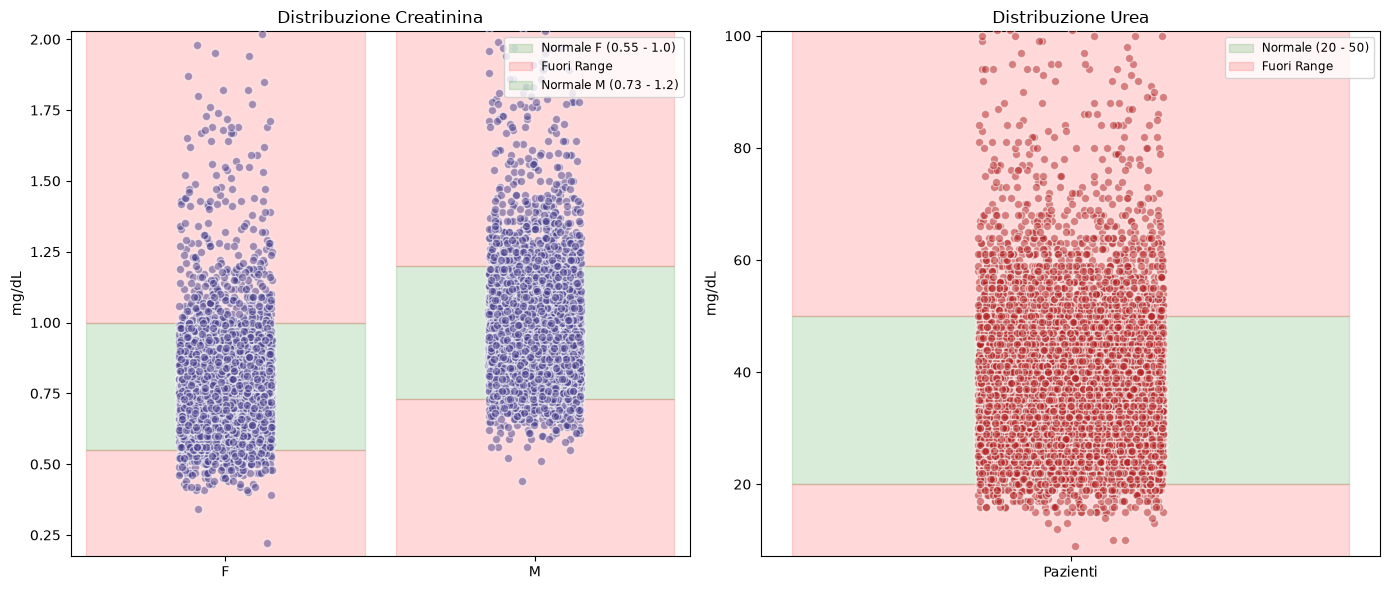

In [52]:
parametri = ['Creatinina', 'Urea']
colori_plot = ['darkslateblue', 'firebrick']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, param, color in zip(axes, parametri, colori_plot):
    
    if param == 'Creatinina':
        df_drop_eta['Gruppo'] = df_drop_eta['Genere']
        order = ['F', 'M']
        order = [cat for cat in order if cat in df_drop_eta['Gruppo'].unique()]
        limiti = {'F': (0.55, 1.0), 'M': (0.73, 1.2)}
    else:
        df_drop_eta['Gruppo'] = 'Pazienti'
        order = ['Pazienti']
        limiti = {'Pazienti': (20, 50)}
        
    q99 = df_drop_eta[param].dropna().quantile(0.99)
    limite_max_normale = max([v[1] for v in limiti.values()])
    
    y_min = max(0, df_drop_eta[param].min() * 0.8)
    y_max = max(q99 * 1.2, limite_max_normale * 1.5)
    
    fuori_range_inserito = False

    for i, cat in enumerate(order):
        vmin, vmax = limiti[cat]
        x_range = [i + 0.55, i + 1.45]
        
        lbl_v = f"Normale {cat} ({vmin} - {vmax})" if cat != 'Pazienti' else f"Normale ({vmin} - {vmax})"
        lbl_r = "Fuori Range" if not fuori_range_inserito else ""
        fuori_range_inserito = True
        
        ax.fill_between(x_range, vmin, vmax, color='green', alpha=0.15, label=lbl_v, zorder=0)
        ax.fill_between(x_range, -100, vmin, color='red', alpha=0.15, label=lbl_r, zorder=0)
        ax.fill_between(x_range, vmax, y_max * 10, color='red', alpha=0.15, zorder=0)

        subset = df_drop_eta[df_drop_eta['Gruppo'] == cat][param].dropna()
        x_jitter = np.random.uniform(i + 0.85, i + 1.15, size=len(subset))
        ax.scatter(x_jitter, subset, alpha=0.5, c=color, edgecolors='white', zorder=3)

    ax.set_title(f"Distribuzione {param}")
    ax.set_ylabel("mg/dL")
    ax.set_xticks(np.arange(1, len(order) + 1))
    ax.set_xticklabels(order)
    ax.set_xlim(0.5, len(order) + 0.5)
    ax.set_ylim(bottom=y_min, top=y_max)
    ax.legend(loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

In [53]:
print(f"Creatinina - min: {df_drop_eta['Creatinina'].min()} mg/dL | max: {df_drop_eta['Creatinina'].max()} mg/dL")
print(f"Urea - min: {df_drop_eta['Urea'].min()} mg/dL | max: {df_drop_eta['Urea'].max()} mg/dL")

Creatinina - min: 0.22 mg/dL | max: 3.56 mg/dL
Urea - min: 9.0 mg/dL | max: 148.0 mg/dL


In [54]:
df_drop_eta.Creatinina.describe().round(1)

count    11803.0
mean         0.9
std          0.2
min          0.2
25%          0.7
50%          0.8
75%          1.0
max          3.6
Name: Creatinina, dtype: float64

In [55]:
df_drop_eta.Urea.describe().round(1)

count    11803.0
mean        37.5
std         12.5
min          9.0
25%         30.0
50%         36.0
75%         43.0
max        148.0
Name: Urea, dtype: float64

## Tabella con recap dei valori

In [57]:
def genera_tabella_anomalie_pulita(df):
    risultati = []
    
    categorie_mappa = {
        'Glucosio': '1. PARAMETRI GLICEMICI',
        'Trigliceridi': '2. PARAMETRI LIPIDICI',
        'Colesterolo LDL': '2. PARAMETRI LIPIDICI',
        'Colesterolo totale': '2. PARAMETRI LIPIDICI',
        'Colesterolo HDL': '2. PARAMETRI LIPIDICI',
        'Aspartato Aminotransferasi (AST)': '3. PARAMETRI EPATICI',
        'Alanina aminotransferasi (ALT)': '3. PARAMETRI EPATICI',
        'Piastrine': '4. EMOCROMO (CBC)',
        'RDW-CV': '4. EMOCROMO (CBC)',
        'Neutrofili': '4. EMOCROMO (CBC)',
        'Linfociti': '4. EMOCROMO (CBC)',
        'Urea': '5. MARCATORI METABOLICI E RENALI',
        'Creatinina': '5. MARCATORI METABOLICI E RENALI'
    }
    
    regole_range = {
        'Glucosio': lambda d: (pd.Series(70, index=d.index), pd.Series(99, index=d.index)),
        'Trigliceridi': lambda d: (pd.Series(0, index=d.index), pd.Series(150, index=d.index)),
        'Colesterolo LDL': lambda d: (pd.Series(0, index=d.index), pd.Series(115, index=d.index)),
        'Colesterolo totale': lambda d: (pd.Series(0, index=d.index), pd.Series(190, index=d.index)),
        'Aspartato Aminotransferasi (AST)': lambda d: (pd.Series(0, index=d.index), pd.Series(34, index=d.index)),
        'Urea': lambda d: (pd.Series(20, index=d.index), pd.Series(50, index=d.index)),
        'Piastrine': lambda d: (pd.Series(150, index=d.index), pd.Series(450, index=d.index)),
        'RDW-CV': lambda d: (pd.Series(9.5, index=d.index), pd.Series(18.8, index=d.index)),
        'Colesterolo HDL': lambda d: (np.where(d['Genere'] == 'M', 40, 45), pd.Series(np.inf, index=d.index)),
        'Alanina aminotransferasi (ALT)': lambda d: (pd.Series(0, index=d.index), np.where(d['Genere'] == 'M', 59, 41)),
        'Creatinina': lambda d: (np.where(d['Genere'] == 'M', 0.73, 0.55), np.where(d['Genere'] == 'M', 1.2, 1.0)),
        'Neutrofili': lambda d: (np.where(d['Età'] > 64, 1.79, 1.88), np.where(d['Età'] > 64, 10.79, 8.34)),
        'Linfociti': lambda d: (np.where(d['Età'] > 64, 0.91, 1.14), np.where(d['Età'] > 64, 3.91, 4.07))
    }
    
    for biomarcatore, calcola_limiti in regole_range.items():
        if biomarcatore in df.columns:
            limite_lln, limite_uln = calcola_limiti(df)
            valori = df[biomarcatore]
            
            rapporto_uln = valori / limite_uln
            
            sotto_min = (valori < limite_lln).sum()
            basso_x2  = (valori < (limite_lln / 2)).sum()
            basso_x3  = (valori < (limite_lln / 3)).sum()
            basso_x4  = (valori < (limite_lln / 4)).sum()
            basso_gt4 = (valori < (limite_lln / 4)).sum()
            
            sopra_max = (valori > limite_uln).sum()
            alto_x2   = (rapporto_uln > 2.0).sum()
            alto_x3   = (rapporto_uln > 3.0).sum()
            alto_x4   = (rapporto_uln > 4.0).sum()
            alto_gt4  = (rapporto_uln > 4.0).sum()
            
            risultati.append({
                'Categoria': categorie_mappa.get(biomarcatore, 'ALTRO'),
                'Biomarcatore': biomarcatore,
                'Min': valori.min(),
                'Max': valori.max(),
                
                'Sballati IN BASSO': sotto_min,
                '(-) Doppio': basso_x2,
                '(-) Triplo': basso_x3,
                '(-) Quadruplo': basso_x4,
                '(-) Oltre': basso_gt4,
                
                'Sballati IN ALTO': sopra_max,
                '(+) Doppio': alto_x2,
                '(+) Triplo': alto_x3,
                '(+) Quadruplo': alto_x4,
                '(+) Oltre': alto_gt4
            })
            
    df_report = pd.DataFrame(risultati)
    
    df_report = df_report.sort_values(by=['Categoria', 'Biomarcatore']).reset_index(drop=True)
    return df_report

df_anomalie_unico = genera_tabella_anomalie_pulita(df_drop_eta)

tabella_stilizzata = (df_anomalie_unico.style.set_properties(**{'font-weight': 'bold'}, subset=['Categoria', 'Biomarcatore']).hide(axis='index'))

tabella_stilizzata

AttributeError: The '.style' accessor requires jinja2

In [ ]:
regole_range = {
    'Glucosio': lambda d: (pd.Series(70, index=d.index), pd.Series(99, index=d.index)),
    'Trigliceridi': lambda d: (pd.Series(0, index=d.index), pd.Series(150, index=d.index)),
    'Colesterolo LDL': lambda d: (pd.Series(0, index=d.index), pd.Series(115, index=d.index)),
    'Colesterolo totale': lambda d: (pd.Series(0, index=d.index), pd.Series(190, index=d.index)),
    'Aspartato Aminotransferasi (AST)': lambda d: (pd.Series(0, index=d.index), pd.Series(34, index=d.index)),
    'Urea': lambda d: (pd.Series(20, index=d.index), pd.Series(50, index=d.index)),
    'Piastrine': lambda d: (pd.Series(150, index=d.index), pd.Series(450, index=d.index)),
    'RDW-CV': lambda d: (pd.Series(9.5, index=d.index), pd.Series(18.8, index=d.index)),
    'Colesterolo HDL': lambda d: (np.where(d['Genere'] == 'M', 40, 45), pd.Series(np.inf, index=d.index)),
    'Alanina aminotransferasi (ALT)': lambda d: (pd.Series(0, index=d.index), np.where(d['Genere'] == 'M', 59, 41)),
    'Creatinina': lambda d: (np.where(d['Genere'] == 'M', 0.73, 0.55), np.where(d['Genere'] == 'M', 1.2, 1.0)),
    'Neutrofili': lambda d: (np.where(d['Età'] > 64, 1.79, 1.88), np.where(d['Età'] > 64, 10.79, 8.34)),
    'Linfociti': lambda d: (np.where(d['Età'] > 64, 0.91, 1.14), np.where(d['Età'] > 64, 3.91, 4.07))
}

totale_generale_basso = 0
totale_generale_alto = 0

for biomarcatore, calcola_limiti in regole_range.items():
    if biomarcatore in df_drop_eta.columns:
        limite_lln, limite_uln = calcola_limiti(df_drop_eta)
        valori = df_drop_eta[biomarcatore]
        
        basso_x2 = (valori < (limite_lln / 2)).sum()
        alto_x2 = (valori > (limite_uln * 2)).sum()
        totale_parametro_x2 = basso_x2 + alto_x2
        
        totale_generale_basso += basso_x2
        totale_generale_alto += alto_x2
        
        print(f"{biomarcatore}: {totale_parametro_x2} oltre x2 ({alto_x2} in alto, {basso_x2} in basso)")

print("\n" + "="*65)
print(f" CONTEGGIO TOTALE DELLE ANOMALIE OLTRE X2 NELL'INTERO DATASET")
print("="*65)
print(f" Totale valori sballati IN BASSO (minori di metà range):{totale_generale_basso}")
print(f" Totale valori sballati IN ALTO  (maggiori del doppio):{totale_generale_alto}")
print("-"*65)
print(f" GRANDE TOTALE COMPLESSIVO (Sotto + Sopra):{totale_generale_basso + totale_generale_alto}")
print("="*65)

Glucosio: 83 oltre x2 (83 in alto, 0 in basso)
Trigliceridi: 156 oltre x2 (156 in alto, 0 in basso)
Colesterolo LDL: 48 oltre x2 (48 in alto, 0 in basso)
Colesterolo totale: 0 oltre x2 (0 in alto, 0 in basso)
Aspartato Aminotransferasi (AST): 79 oltre x2 (79 in alto, 0 in basso)
Urea: 62 oltre x2 (61 in alto, 1 in basso)
Piastrine: 7 oltre x2 (0 in alto, 7 in basso)
RDW-CV: 0 oltre x2 (0 in alto, 0 in basso)
Colesterolo HDL: 9 oltre x2 (0 in alto, 9 in basso)
Alanina aminotransferasi (ALT): 70 oltre x2 (70 in alto, 0 in basso)
Creatinina: 44 oltre x2 (42 in alto, 2 in basso)
Neutrofili: 20 oltre x2 (4 in alto, 16 in basso)
Linfociti: 13 oltre x2 (8 in alto, 5 in basso)

 CONTEGGIO TOTALE DELLE ANOMALIE OLTRE X2 NELL'INTERO DATASET
 Totale valori sballati IN BASSO (minori di metà range):40
 Totale valori sballati IN ALTO  (maggiori del doppio):551
-----------------------------------------------------------------
 GRANDE TOTALE COMPLESSIVO (Sotto + Sopra):591


In [ ]:
df_drop_eta

,id_num,Data dell'Episodio,Genere,Età,Alanina aminotransferasi (ALT),Aspartato Aminotransferasi (AST),Colesterolo HDL,Colesterolo LDL,Colesterolo totale,Creatinina,Glucosio,Linfociti,Neutrofili,Piastrine,RDW-CV,Trigliceridi,Urea,Gruppo_Età,Gruppo
0,1,2022-05-14,M,59,26,21,37,167,222,0.78,129,2.23,4.28,257,13.4,185,31.0,>14 anni,Pazienti
1,2,2025-12-16,M,85,33,24,81,34,130,1.11,108,1.02,4.58,231,14.0,66,45.0,>14 anni,Pazienti
2,3,2022-10-24,F,58,21,20,41,110,158,0.80,181,2.67,4.51,358,15.9,208,28.0,>14 anni,Pazienti
3,4,2026-03-10,F,58,16,16,71,113,191,0.74,86,1.51,2.55,248,12.7,71,21.0,>14 anni,Pazienti
4,5,2025-05-14,F,49,11,20,78,111,206,0.78,96,1.34,2.66,211,12.8,44,37.0,>14 anni,Pazienti
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16256,12495,2026-02-05,F,42,17,26,52,144,212,0.83,101,1.72,1.85,277,13.5,74,24.0,>14 anni,Pazienti
16258,12497,2026-03-27,M,31,28,41,28,55,94,1.29,85,1.71,5.50,259,11.8,63,55.0,>14 anni,Pazienti
16259,12498,2026-02-27,F,78,18,22,59,73,147,0.91,92,0.46,2.99,244,12.7,166,40.0,>14 anni,Pazienti
16260,12499,2026-04-29,F,61,17,18,72,126,216,0.77,137,1.60,2.80,251,12.2,95,48.0,>14 anni,Pazienti


# Considerazioni:

L'obiettivo del progetto è stimare l'**età biochimica** di un paziente a partire da un insieme di parametri, usando tecniche di machine learning o deep learning. Il dataset di partenza contava **16.262 pazienti**. Dopo la pulizia iniziale (esclusione fasce d'età estreme e rimozione dei pazienti con età incongruente tra esami) si arriva a **11.860 pazienti** utilizzabili. Prima di addestrare qualsiasi modello, è necessario capire la qualità del dataset e decidere come trattare i dati problematici. Questo documento raccoglie le osservazioni fatte durante l'esplorazione e le scelte di preprocessing che ne derivano.

---

## 1. Contesto dei Dati

Un'assunzione fondamentale da fare subito riguarda la natura del dataset: i pazienti presenti sono persone che si sono recate in laboratorio per fare analisi cliniche. Questo significa che, con alta probabilità, **la maggior parte di loro ha qualche condizione medica in corso**, che sia lieve o grave. Di conseguenza, i valori biochimici nel dataset non rappresentano necessariamente una popolazione sana, e questo è un limite che il modello dovrà in qualche modo gestire.

---

## 2. Fascia d'Età — Cap a 18–90 anni

### Problema
Nel dataset sono presenti pazienti con età inferiore a 18 anni (251 casi) e superiore a 90 anni (320 casi). Questi numeri sono molto bassi rispetto al totale del dataset.

| Fascia | Pazienti |
|--------|---------|
| Età < 18 | 251 |
| Età > 90 | 320 |

### Perché è un problema
Nel deep learning, avere pochi esempi per una determinata fascia significa che la rete non ha abbastanza dati per imparare i pattern di quella fascia. Il rischio è che il modello li tratti come rumore, li ignori, o peggio li impari male introducendo errori sistematici. Inoltre, i parametri biochimici nei minori si comportano in modo molto diverso rispetto agli adulti (crescita, sviluppo ormonale, ecc.), e lo stesso vale per gli anziani.

### Scelta
Abbiamo deciso di **escludere** i pazienti fuori dalla fascia 18–90 anni. 571 pazienti su un dataset di 16.262 parametri, questo migliorerà la qualità dell'addestramento di avendo una popolazione più omogenea.

---

## 3. Outlier dei Biomarcatori

### Problema
Diversi biomarcatori presentano valori estremi, in alcuni casi anche oltre 4 volte il range di riferimento clinico. Questo è in parte spiegabile dal fatto che il dataset proviene da un laboratorio, ma i valori più estremi potrebbero essere anche errori di misurazione o di inserimento dati.

La tabella seguente riassume la situazione:

| Categoria | Biomarcatore | Min | Max | Sballati IN BASSO | (−) Doppio | (−) Triplo | (−) Quadruplo | (−) Oltre | Sballati IN ALTO | (+) Doppio | (+) Triplo | (+) Quadruplo | (+) Oltre |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 1. Parametri Glicemici | Glucosio | 44.0 | 445.0 | 22 | 0 | 0 | 0 | 0 | 4293 | 83 | 21 | 3 | 3 |
| 2. Parametri Lipidici | Colesterolo HDL | 13.0 | 148.0 | 1483 | 9 | 2 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| 2. Parametri Lipidici | Colesterolo LDL | 12.0 | 290.0 | 0 | 0 | 0 | 0 | 0 | 5867 | 48 | 0 | 0 | 0 |
| 2. Parametri Lipidici | Colesterolo totale | 62.0 | 363.0 | 0 | 0 | 0 | 0 | 0 | 5714 | 0 | 0 | 0 | 0 |
| 2. Parametri Lipidici | Trigliceridi | 22.0 | 1725.0 | 0 | 0 | 0 | 0 | 0 | 1721 | 156 | 42 | 20 | 20 |
| 3. Parametri Epatici | ALT | 4.0 | 513.0 | 0 | 0 | 0 | 0 | 0 | 541 | 70 | 26 | 8 | 8 |
| 3. Parametri Epatici | AST | 8.0 | 531.0 | 0 | 0 | 0 | 0 | 0 | 765 | 79 | 26 | 11 | 11 |
| 4. Emocromo (CBC) | Linfociti | 0.31 | 82.3 | 199 | 5 | 0 | 0 | 0 | 189 | 8 | 7 | 5 | 5 |
| 4. Emocromo (CBC) | Neutrofili | 0.36 | 20.69 | 477 | 16 | 2 | 2 | 2 | 68 | 4 | 0 | 0 | 0 |
| 4. Emocromo (CBC) | Piastrine | 8.0 | 757.0 | 369 | 7 | 3 | 2 | 2 | 84 | 0 | 0 | 0 | 0 |
| 4. Emocromo (CBC) | RDW-CV | 11.1 | 26.5 | 0 | 0 | 0 | 0 | 0 | 99 | 0 | 0 | 0 | 0 |
| 5. Marcatori Metabolici e Renali | Creatinina | 0.22 | 7.17 | 485 | 2 | 0 | 0 | 0 | 844 | 42 | 11 | 4 | 4 |
| 5. Marcatori Metabolici e Renali | Urea | 9.0 | 285.0 | 209 | 1 | 0 | 0 | 0 | 1206 | 61 | 10 | 6 | 6 |

In totale, i valori con deviazione pari o superiore al doppio del range (sia verso l'alto che verso il basso) sono **591**.

### Ragionamento per decidere cosa fare

Non tutti gli outlier vanno trattati allo stesso modo. Bisogna distinguere due situazioni:

**Caso A — Outlier verosimilmente reali (patologie note)**
Valori come il colesterolo LDL a 290, i trigliceridi a 1725 o la creatinina a 7.17 sono alti ma clinicamente possibili . Eliminarli significherebbe perdere informazioni reali su come certi parametri correlano con l'età in pazienti malati. In questi casi ha più senso applicare un **capping**, portando i valori oltre soglia a un valore massimo di riferimento, senza eliminare il record.

**Caso B — Outlier probabilmente errati**
Valori come linfociti a 82.3 o piastrine a 8 fanno pensare a errori di misurazione o di inserimento. In questi casi l'**eliminazione** del record è più sicura, perché tenere un dato sbagliato è peggio che perderlo.

### Impatto sull'addestramento

Il comportamento di questi 591 valori dipende fortemente dall'approccio scelto:

**Deep Learning (rete neurale)**
Le reti neurali sono sensibili ai valori in input: un valore troppo fuori range può confondere la rete durante l'addestramento e farle imparare pattern sbagliati. Per questo gli outlier estremi vanno trattati prima di addestrare il modello.

**Machine Learning ad albero (Random Forest, XGBoost, o schemi round-robin simili)**
Gli algoritmi basati su alberi sono nativamente **robusti agli outlier**: i nodi di split lavorano su soglie ordinali, quindi un valore estremo finisce semplicemente in un ramo senza influenzare gli altri. In questo caso i 591 valori sballati potrebbero essere lasciati così com'è senza compromettere l'addestramento — la struttura dell'albero li isola naturalmente.

### Scelta

| Approccio | Trattamento outlier consigliato |
|-----------|-------------------------------|
| **Deep Learning** | Capping obbligatorio per outlier ≤ triplo; eliminazione del record per outlier ≥ quadruplo |
| **ML ad albero** | Nessun intervento necessario; gli outlier vengono gestiti nativamente dall'algoritmo |

In entrambi i casi, i valori con deviazione oltre il quadruplo del range vanno comunque valutati per l'eliminazione, indipendentemente dall'approccio scelto.

---

## 4. Inconsistenza dell'Età per Stesso Paziente

### Problema
Il dataset copre un arco temporale che va dal 2021 ad oggi, quindi molti pazienti sono presenti con più esami effettuati in anni diversi (fino a 5 anni di controlli). Analizzando i dati per ID paziente, abbiamo notato che in diversi casi l'**età risulta invariata** tra un anno e l'altro quindi un paziente che ha fatto le analisi nel 2021 e poi nel 2024 appare con la stessa età in entrambi i record, il che è chiaramente impossibile.

### Perché è un problema
L'età è la nostra **variabile target**: è ciò che il modello deve imparare a stimare. Se l'età associata ai parametri biochimici è scorretta, stiamo addestrando il modello su dati inconsistenti.

### Scelta
Abbiamo deciso di **rimuovere tutti i pazienti** per cui l'età risulta incongruente tra esami di anni diversi. Mantenere questi record significherebbe introdurre rumore direttamente nel target, rendendo l'addestramento inaffidabile. È preferibile perdere quei campioni piuttosto che compromettere la qualità dell'etichetta.

---

## 5. Riepilogo delle Scelte

| Problema | Scelta | Motivazione |
|----------|--------|-------------|
| Pazienti < 18 anni (251) | Esclusione | Troppo pochi campioni, biologia diversa |
| Pazienti > 90 anni (320) | Esclusione | Troppo pochi campioni |
| Età incongruente tra esami dello stesso paziente | Esclusione del paziente | Errore sul target, compromette l'addestramento |
| Outlier ≤ triplo (con DL) | Capping al valore di riferimento | Le reti neurali sono sensibili alla scala, gli outlier sabotano il gradiente |
| Outlier ≤ triplo (con ML ad albero) | Nessun intervento | Gli alberi sono robusti agli outlier per costruzione |
| Outlier ≥ quadruplo (entrambi) | Eliminazione del record | Probabile errore di misurazione, inaffidabile in ogni contesto |

# Calcolo 11 Score Clinici

## Insulino-Resistenza

**TyG Index**: _ln ((Trigliceridi (mg/dL)  ×  Glicemia (mg/dL)) / 2)_ Indice surrogato dell’insulino-resistenza ottenuto da trigliceridi e glicemia a digiuno. È considerato un marker semplice e accessibile del deterioramento metabolico e del rischio cardiometabolico. Numerosi studi hanno mostrato una forte associazione tra TyG elevato e sindrome metabolica, steatosi epatica, diabete tipo 2 e aumento del rischio cardiovascolare. Valori elevati suggeriscono una ridotta risposta periferica all’insulina e una maggiore probabilità di stato pro-infiammatorio e pro-aterogeno.

**TG/HDL Ratio**: _Trigliceridi (mg/dL)  /  HDL (mg/dL)_ Rapporto tra trigliceridi e colesterolo HDL utilizzato come indicatore indiretto di insulino-resistenza e presenza di LDL piccole e dense aterogene. È frequentemente associato a rischio cardiovascolare precoce e sindrome metabolica. Questo indice integra una componente pro-aterogena, rappresentata dai trigliceridi elevati, con una componente protettiva cardiovascolare, rappresentata dall’HDL. Per questo motivo il rapporto è spesso più informativo dei singoli parametri isolati.

In [ ]:
df_nuovo_pulito = pd.read_csv("data/df_clean.csv", parse_dates=True)

In [ ]:
df_nuovo_pulito["TyG Index"] = np.log((df_nuovo_pulito["Trigliceridi"] * df_nuovo_pulito["Glucosio"])/2).round(2)
df_nuovo_pulito["TyG Index"]

0        9.39
1        8.18
2        9.84
3        8.02
4        7.66
         ... 
15713    7.89
15714    8.02
15715    8.94
15716    8.78
15717    8.48
Name: TyG Index, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito["TyG Index"].describe().round(2)

count    15718.00
mean         8.46
std          0.50
min          6.90
25%          8.11
50%          8.41
75%          8.76
max         10.68
Name: TyG Index, dtype: float64

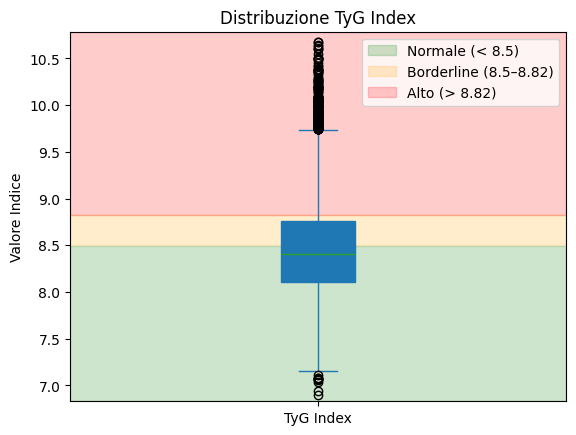

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["TyG Index"].min() * 0.99
y_max = df_nuovo_pulito["TyG Index"].max() * 1.01

ax.axhspan(y_min, 8.49, color="green", alpha=0.2, label="Normale (< 8.5)")
ax.axhspan(8.5, 8.82, color="orange", alpha=0.2, label="Borderline (8.5–8.82)")
ax.axhspan(8.83, y_max, color="red", alpha=0.2, label="Alto (> 8.82)")

df_nuovo_pulito["TyG Index"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Valore Indice")
ax.set_title("Distribuzione TyG Index")

plt.show()

In [ ]:
df_nuovo_pulito["TG/HDL Ratio"] = (df_nuovo_pulito["Trigliceridi"] / df_nuovo_pulito["Colesterolo HDL"]).round(2)
df_nuovo_pulito["TG/HDL Ratio"]

0        5.00
1        0.81
2        5.07
3        1.00
4        0.56
         ... 
15713    2.25
15714    1.04
15715    2.81
15716    1.32
15717    1.65
Name: TG/HDL Ratio, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito["TG/HDL Ratio"].describe().round(2)

count    15718.00
mean         2.08
std          1.49
min          0.28
25%          1.12
50%          1.65
75%          2.52
max         17.15
Name: TG/HDL Ratio, dtype: float64

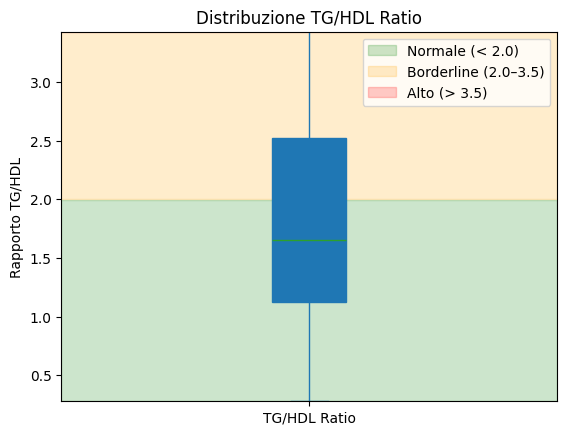

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["TG/HDL Ratio"].min() * 0.99
y_max = df_nuovo_pulito["TG/HDL Ratio"].max() * 0.2

ax.axhspan(y_min, 1.99, color="green", alpha=0.2, label="Normale (< 2.0)")
ax.axhspan(2.0, 3.5, color="orange", alpha=0.2, label="Borderline (2.0–3.5)")
ax.axhspan(3.51, y_max, color="red", alpha=0.2, label="Alto (> 3.5)")

df_nuovo_pulito["TG/HDL Ratio"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto TG/HDL")
ax.set_title("Distribuzione TG/HDL Ratio")

plt.show()

## Rischio CV Lipidico

**Castelli Index I**: _Colest. Totale / HDL_ Indice lipidico utilizzato per valutare il rischio cardiovascolare globale. Integra colesterolo totale e HDL in un singolo rapporto interpretabile. Valori elevati indicano un profilo lipidico sfavorevole e una maggiore probabilità di sviluppo di aterosclerosi e malattia cardiovascolare. 

**Castelli Index II**: _LDL / HDL_ Rapporto tra colesterolo LDL e colesterolo HDL. Esprime il bilancio tra componente aterogena e componente protettiva del profilo lipidico. Rispetto al Castelli Index I, che utilizza il colesterolo totale, è più focalizzato sul rischio aterosclerotico, perché confronta direttamente LDL, principale frazione pro-aterogena, e HDL, coinvolto nel trasporto inverso del colesterolo.

**Non-HDL Colesterolo**: _Colest. Totale − HDL_ Il colesterolo non-HDL rappresenta la quota totale di lipoproteine aterogene circolanti. Include LDL, VLDL, IDL e altre particelle ricche in trigliceridi coinvolte nello sviluppo dell’aterosclerosi. A differenza del solo LDL-C, fornisce una stima più globale del burden lipidico aterogeno, risultando particolarmente utile nei soggetti con sindrome metabolica, ipertrigliceridemia e insulino-resistenza. Dal punto di vista fisiopatologico, valori elevati riflettono un aumento delle particelle pro-aterogene circolanti e si associano a maggiore rischio cardiovascolare e deterioramento cardiometabolico.

In [ ]:
df_nuovo_pulito["Castelli Index I"] = (df_nuovo_pulito["Colesterolo totale"] / df_nuovo_pulito["Colesterolo HDL"]).round(2)
df_nuovo_pulito["Castelli Index I"]

0        6.00
1        1.60
2        3.85
3        2.69
4        2.64
         ... 
15713    3.36
15714    3.06
15715    2.49
15716    3.00
15717    3.69
Name: Castelli Index I, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito["Castelli Index I"].describe().round(2)

count    15718.00
mean         3.44
std          1.00
min          1.42
25%          2.71
50%          3.25
75%          4.00
max         16.07
Name: Castelli Index I, dtype: float64

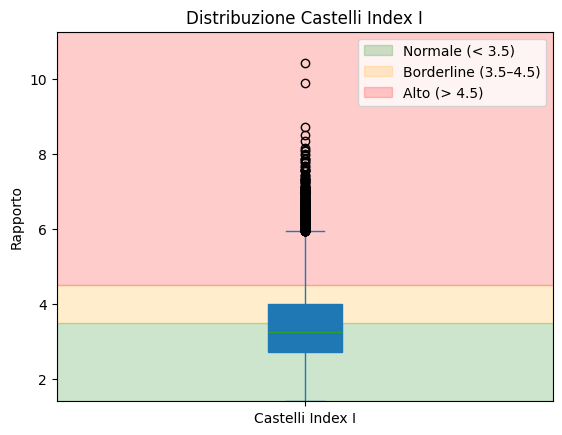

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["Castelli Index I"].min() * 0.99
y_max = df_nuovo_pulito["Castelli Index I"].max() * 0.7

ax.axhspan(y_min, 3.49, color="green", alpha=0.2, label="Normale (< 3.5)")
ax.axhspan(3.5, 4.5, color="orange", alpha=0.2, label="Borderline (3.5–4.5)")
ax.axhspan(4.51, y_max, color="red", alpha=0.2, label="Alto (> 4.5)")

df_nuovo_pulito["Castelli Index I"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione Castelli Index I")

plt.show()

In [ ]:
df_nuovo_pulito["Castelli Index II"] = (df_nuovo_pulito["Colesterolo LDL"] / df_nuovo_pulito["Colesterolo HDL"]).round(2)
df_nuovo_pulito["Castelli Index II"]

0        4.51
1        0.42
2        2.68
3        1.59
4        1.42
         ... 
15713    1.96
15714    1.84
15715    1.24
15716    1.75
15717    2.55
Name: Castelli Index II, Length: 15718, dtype: float64

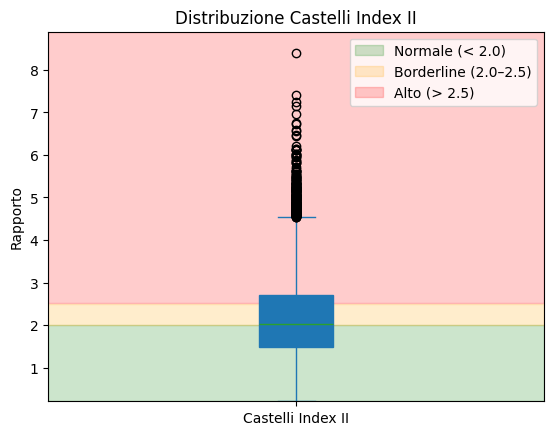

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["Castelli Index II"].min() * 0.99
y_max = df_nuovo_pulito["Castelli Index II"].max() * 0.7

ax.axhspan(y_min, 1.99, color="green", alpha=0.2, label="Normale (< 2.0)")
ax.axhspan(2.0, 2.5, color="orange", alpha=0.2, label="Borderline (2.0–2.5)")
ax.axhspan(2.51, y_max, color="red", alpha=0.2, label="Alto (> 2.5)")

df_nuovo_pulito["Castelli Index II"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione Castelli Index II")

plt.show()

In [ ]:
df_nuovo_pulito["Non-HDL Colesterolo"] = (df_nuovo_pulito["Colesterolo totale"] - df_nuovo_pulito["Colesterolo HDL"])
df_nuovo_pulito["Non-HDL Colesterolo"]

0        185
1         49
2        117
3        120
4        128
        ... 
15713     66
15714    140
15715     88
15716    144
15717    137
Name: Non-HDL Colesterolo, Length: 15718, dtype: int64

In [ ]:
df_nuovo_pulito["Non-HDL Colesterolo"].describe().round(2)

count    15718.00
mean       130.83
std         37.57
min         29.00
25%        105.00
50%        129.00
75%        155.00
max        311.00
Name: Non-HDL Colesterolo, dtype: float64

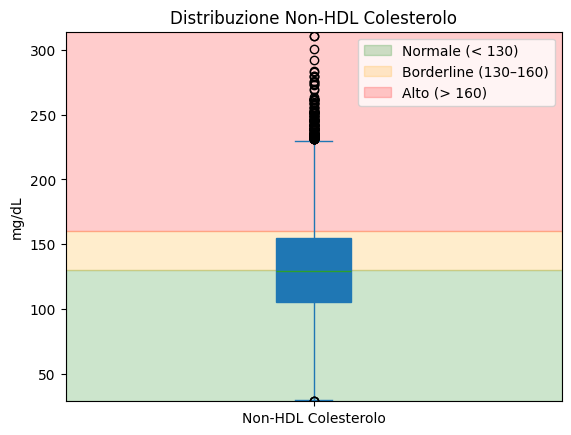

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["Non-HDL Colesterolo"].min() * 0.99
y_max = df_nuovo_pulito["Non-HDL Colesterolo"].max() * 1.01

ax.axhspan(y_min, 129.99, color="green", alpha=0.2, label="Normale (< 130)")
ax.axhspan(130, 160, color="orange", alpha=0.2, label="Borderline (130–160)")
ax.axhspan(160.01, y_max, color="red", alpha=0.2, label="Alto (> 160)")

df_nuovo_pulito["Non-HDL Colesterolo"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("mg/dL")
ax.set_title("Distribuzione Non-HDL Colesterolo")

plt.show()

## Profilo Epatico

**FIB-4**: _( Età × AST )  /  ( PLT  ×  √ALT )_ Score non invasivo per stimare il rischio di fibrosi epatica significativa. Utilizza età, transaminasi e conta piastrinica. È ampiamente impiegato nello screening della MASLD e delle epatopatie croniche.

**De Ritis (AST/ALT)**: _AST  /  ALT_ Rapporto tra AST e ALT utilizzato nella valutazione del pattern di danno epatico. Valori inferiori a 1 sono frequentemente associati a steatosi metabolica, mentre valori superiori possono suggerire fibrosi avanzata o epatopatia alcolica.

In [ ]:
df_nuovo_pulito["FIB-4"] = ((df_nuovo_pulito.Età * df_nuovo_pulito["Aspartato Aminotransferasi (AST)"]) / (df_nuovo_pulito.Piastrine * (np.sqrt(df_nuovo_pulito["Alanina aminotransferasi (ALT)"])))).round(2)
df_nuovo_pulito["FIB-4"]

0        0.88
1        1.54
2        0.66
3        0.92
4        1.37
         ... 
15713    0.93
15714    0.84
15715    1.64
15716    1.06
15717    1.05
Name: FIB-4, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito["FIB-4"].describe().round(2)

count    15718.00
mean         1.25
std          0.81
min          0.13
25%          0.77
50%          1.10
75%          1.56
max         46.75
Name: FIB-4, dtype: float64

In [ ]:
df_nuovo_pulito

,id_num,Data dell'Episodio,Data di nascita,Età,Genere,Alanina aminotransferasi (ALT),Aspartato Aminotransferasi (AST),Colesterolo HDL,Colesterolo LDL,Colesterolo totale,...,Piastrine,RDW-CV,Trigliceridi,Urea,TyG Index,TG/HDL Ratio,Castelli Index I,Castelli Index II,Non-HDL Colesterolo,FIB-4
0,1,2022-05-14,1966-09-19,55,M,26,21,37,167,222,...,257,13.4,185,31.0,9.39,5.00,6.00,4.51,185,0.88
1,2,2025-12-16,1940-05-27,85,M,33,24,81,34,130,...,231,14.0,66,45.0,8.18,0.81,1.60,0.42,49,1.54
2,3,2022-10-24,1968-03-20,54,F,21,20,41,110,158,...,358,15.9,208,28.0,9.84,5.07,3.85,2.68,117,0.66
3,4,2026-03-10,1968-05-11,57,F,16,16,71,113,191,...,248,12.7,71,21.0,8.02,1.00,2.69,1.59,120,0.92
4,5,2025-05-14,1977-01-14,48,F,11,20,78,111,206,...,211,12.8,44,37.0,7.66,0.56,2.64,1.42,128,1.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15713,12497,2026-03-27,1994-06-24,31,M,28,41,28,55,94,...,259,11.8,63,55.0,7.89,2.25,3.36,1.96,66,0.93
15714,479,2026-02-11,1970-04-08,55,F,20,21,68,125,208,...,309,12.9,71,48.0,8.02,1.04,3.06,1.84,140,0.84
15715,12498,2026-02-27,1948-04-03,77,F,18,22,59,73,147,...,244,12.7,166,40.0,8.94,2.81,2.49,1.24,88,1.64
15716,12499,2026-04-29,1964-06-15,61,F,17,18,72,126,216,...,251,12.2,95,48.0,8.78,1.32,3.00,1.75,144,1.06


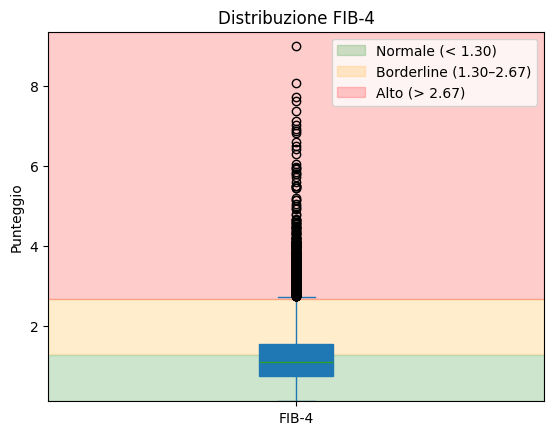

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["FIB-4"].min() * 0.99
y_max = df_nuovo_pulito["FIB-4"].max() * 0.2

ax.axhspan(y_min, 1.29, color="green", alpha=0.2, label="Normale (< 1.30)")
ax.axhspan(1.30, 2.67, color="orange", alpha=0.2, label="Borderline (1.30–2.67)")
ax.axhspan(2.68, y_max, color="red", alpha=0.2, label="Alto (> 2.67)")

df_nuovo_pulito["FIB-4"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Punteggio")
ax.set_title("Distribuzione FIB-4")

plt.show()

In [ ]:
df_nuovo_pulito["De Ritis (AST/ALT)"] = (df_nuovo_pulito["Aspartato Aminotransferasi (AST)"] / df_nuovo_pulito["Alanina aminotransferasi (ALT)"]).round(2)
df_nuovo_pulito["De Ritis (AST/ALT)"]

0        0.81
1        0.73
2        0.95
3        1.00
4        1.82
         ... 
15713    1.46
15714    1.05
15715    1.22
15716    1.06
15717    0.85
Name: De Ritis (AST/ALT), Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito["De Ritis (AST/ALT)"].describe().round(2)

count    15718.00
mean         1.11
std          0.38
min          0.19
25%          0.84
50%          1.06
75%          1.31
max          6.56
Name: De Ritis (AST/ALT), dtype: float64

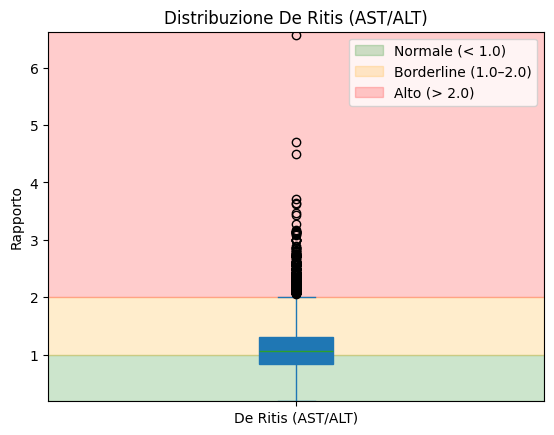

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["De Ritis (AST/ALT)"].min() * 0.99
y_max = df_nuovo_pulito["De Ritis (AST/ALT)"].max() * 1.01

ax.axhspan(y_min, 0.99, color="green", alpha=0.2, label="Normale (< 1.0)")
ax.axhspan(1.0, 2.0, color="orange", alpha=0.2, label="Borderline (1.0–2.0)")
ax.axhspan(2.01, y_max, color="red", alpha=0.2, label="Alto (> 2.0)")

df_nuovo_pulito["De Ritis (AST/ALT)"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione De Ritis (AST/ALT)")

plt.show()

## Indici Infiammatori Ematici

**NLR**: _Neutrofili (×10⁹/L)  /  Linfociti (×10⁹/L)_ Indice infiammatorio che esprime il rapporto tra immunità innata e adattativa. È considerato un marker di infiammazione sistemica cronica e viene associato a rischio cardiovascolare, fragilità e inflammaging.

**PLR**: _Piastrine (×10⁹/L)  /  Linfociti (×10⁹/L)_ Indice derivato da piastrine e linfociti utilizzato come marker prognostico infiammatorio. È stato studiato in ambito cardiovascolare, oncologico e metabolico.

**SII**: _( Piastrine  ×  Neutrofili )  /  Linfociti_ Indice composito che integra risposta infiammatoria, immunità innata e attivazione piastrinica. È considerato più robusto rispetto a NLR e PLR isolati nella valutazione del burden infiammatorio sistemico.

In [ ]:
df_nuovo_pulito['NLR'] = (df_nuovo_pulito['Neutrofili'] / df_nuovo_pulito['Linfociti']).round(2)
df_nuovo_pulito['NLR']

0        1.92
1        4.49
2        1.69
3        1.69
4        1.99
         ... 
15713    3.22
15714    1.16
15715    6.50
15716    1.75
15717    1.49
Name: NLR, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito['NLR'].describe().round(2)

count    15718.00
mean         1.80
std          0.97
min          0.12
25%          1.23
50%          1.61
75%          2.13
max         31.19
Name: NLR, dtype: float64

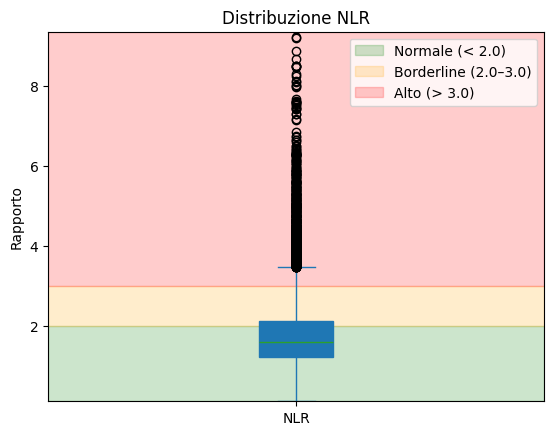

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["NLR"].min() * 0.99
y_max = df_nuovo_pulito["NLR"].max() * 0.3

ax.axhspan(y_min, 1.99, color="green", alpha=0.2, label="Normale (< 2.0)")
ax.axhspan(2.0, 3.0, color="orange", alpha=0.2, label="Borderline (2.0–3.0)")
ax.axhspan(3.01, y_max, color="red", alpha=0.2, label="Alto (> 3.0)")

df_nuovo_pulito["NLR"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione NLR")

plt.show()

In [ ]:
df_nuovo_pulito['PLR'] = (df_nuovo_pulito['Piastrine'] / df_nuovo_pulito['Linfociti']).round(2)
df_nuovo_pulito['PLR']

0        115.25
1        226.47
2        134.08
3        164.24
4        157.46
          ...  
15713    151.46
15714    141.74
15715    530.43
15716    156.88
15717    218.92
Name: PLR, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito['PLR'].describe().round(2)

count    15718.00
mean       122.96
std         47.58
min          3.03
25%         91.98
50%        115.20
75%        143.72
max        832.26
Name: PLR, dtype: float64

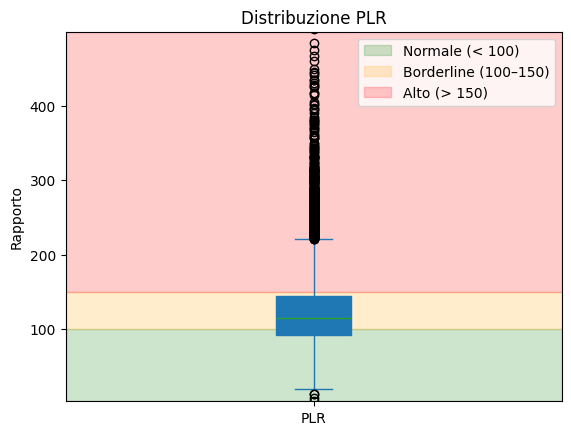

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["PLR"].min() * 0.99
y_max = df_nuovo_pulito["PLR"].max() * 0.6

ax.axhspan(y_min, 99.99, color="green", alpha=0.2, label="Normale (< 100)")
ax.axhspan(100, 150, color="orange", alpha=0.2, label="Borderline (100–150)")
ax.axhspan(150.01, y_max, color="red", alpha=0.2, label="Alto (> 150)")

df_nuovo_pulito["PLR"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione PLR")

plt.show()

In [ ]:
df_nuovo_pulito['SII'] = ((df_nuovo_pulito['Piastrine'] * df['Neutrofili']) / df['Linfociti']).round(2)
df_nuovo_pulito['SII']

0         493.26
1        1037.24
2         604.71
3         418.81
4         418.85
          ...   
15713     436.21
15714     882.68
15715     212.55
15716     483.25
15717     377.52
Name: SII, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito['SII'].describe().round(2)

count    15718.00
mean       441.91
std        274.61
min          6.43
25%        279.36
50%        382.89
75%        530.26
max      10605.81
Name: SII, dtype: float64

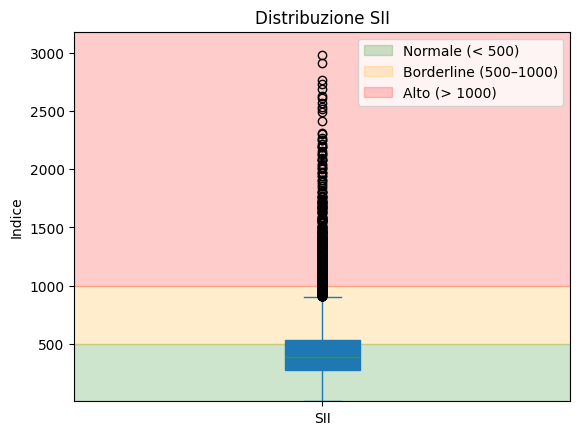

In [ ]:
fig, ax = plt.subplots()

y_min = df_nuovo_pulito["SII"].min() * 0.99
y_max = df_nuovo_pulito["SII"].max() * 0.3

ax.axhspan(y_min, 499.99, color="green", alpha=0.2, label="Normale (< 500)")
ax.axhspan(500, 1000, color="orange", alpha=0.2, label="Borderline (500–1000)")
ax.axhspan(1000.01, y_max, color="red", alpha=0.2, label="Alto (> 1000)")

df_nuovo_pulito["SII"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Indice")
ax.set_title("Distribuzione SII")

plt.show()

## Funzionalità Renale/Metabolica


**Urea / Creatinina**: _Urea (mg/dL)  /  Creatinina (mg/dL)_ Rapporto utilizzato nella valutazione dello stato catabolico, dell’idratazione e della funzione renale. Alterazioni possono riflettere aumentato catabolismo proteico o condizioni pre-renali.

In [ ]:
df_nuovo_pulito['Urea / Creatinina'] = (df_nuovo_pulito['Urea'] / df_nuovo_pulito['Creatinina']).round(2)
df_nuovo_pulito['Urea / Creatinina']

0        39.74
1        40.54
2        35.00
3        28.38
4        47.44
         ...  
15713    42.64
15714    69.57
15715    43.96
15716    62.34
15717    58.21
Name: Urea / Creatinina, Length: 15718, dtype: float64

In [ ]:
df_nuovo_pulito['Urea / Creatinina'].describe().round(2)

count    15718.00
mean        44.72
std         12.46
min         12.99
25%         36.00
50%         43.05
75%         51.61
max        278.57
Name: Urea / Creatinina, dtype: float64

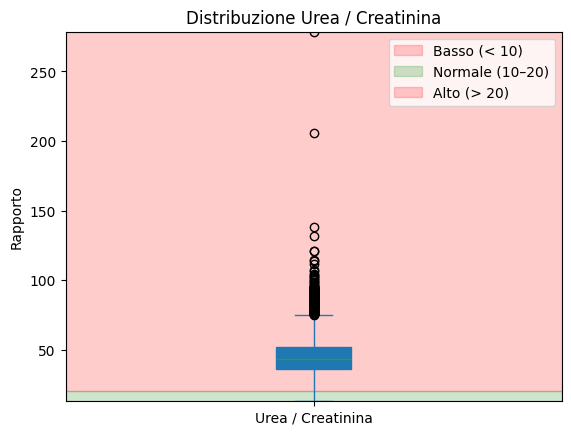

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

y_min = df_nuovo_pulito["Urea / Creatinina"].min() * 0.99
y_max = df_nuovo_pulito["Urea / Creatinina"].max() * 1

ax.axhspan(y_min, 9.99, color="red", alpha=0.2, label="Basso (< 10)")
ax.axhspan(10, 20, color="green", alpha=0.2, label="Normale (10–20)")
ax.axhspan(20.01, y_max, color="red", alpha=0.2, label="Alto (> 20)")

df_nuovo_pulito["Urea / Creatinina"].plot.box(ax=ax, patch_artist=True)

ax.set_ylim(bottom=y_min, top=y_max)

ax.legend(loc="upper right")
ax.set_ylabel("Rapporto")
ax.set_title("Distribuzione Urea / Creatinina")

plt.show()

### Controllo delle medie e confeonto con i valori

In [ ]:
colonne_target = [
    "TyG Index",
    "TG/HDL Ratio",
    "Castelli Index I",
    "Castelli Index II",
    "Non-HDL Colesterolo",
    "FIB-4",
    "De Ritis (AST/ALT)",
    "NLR",
    "PLR",
    "SII",
    "Urea / Creatinina"
]

print(f"Medie degli 11 score clinici\n{df_nuovo_pulito[colonne_target].mean().round(2)}")

Medie degli 11 score clinici
TyG Index                8.46
TG/HDL Ratio             2.08
Castelli Index I         3.44
Castelli Index II        2.17
Non-HDL Colesterolo    130.83
FIB-4                    1.25
De Ritis (AST/ALT)       1.01
NLR                      1.80
PLR                    122.96
SII                    441.91
Urea / Creatinina       44.72
dtype: float64


In [ ]:
print(f"Mediane degli 11 score clinici\n{df_nuovo_pulito[colonne_target].median().round(2)}")

Mediane degli 11 score clinici
TyG Index                8.41
TG/HDL Ratio             1.65
Castelli Index I         3.25
Castelli Index II        2.02
Non-HDL Colesterolo    129.00
FIB-4                    1.10
De Ritis (AST/ALT)       0.94
NLR                      1.61
PLR                    115.20
SII                    382.89
Urea / Creatinina       43.05
dtype: float64


In [ ]:
print(f"Deviazione std degli 11 score clinici\n{df_nuovo_pulito[colonne_target].std().round(2)}")

Deviazione std degli 11 score clinici
TyG Index                0.50
TG/HDL Ratio             1.49
Castelli Index I         1.00
Castelli Index II        0.91
Non-HDL Colesterolo     37.57
FIB-4                    0.81
De Ritis (AST/ALT)       0.36
NLR                      0.97
PLR                     47.58
SII                    274.61
Urea / Creatinina       12.46
dtype: float64


In [ ]:
colonne_score = [
    "TyG Index",
    "TG/HDL Ratio",
    "Castelli Index I",
    "Castelli Index II",
    "Non-HDL Colesterolo",
    "FIB-4",
    "De Ritis (AST/ALT)",
    "NLR",
    "PLR",
    "SII",
    "Urea / Creatinina",
]

soglie = {
    "TyG Index": 8.82,
    "TG/HDL Ratio": 3.5,
    "Castelli Index I": 4.5,
    "Castelli Index II": 2.5,
    "Non-HDL Colesterolo": 160,
    "FIB-4": 2.67,
    "De Ritis (AST/ALT)": 2.0,
    "NLR": 3.0,
    "PLR": 150,
    "SII": 1000,
    "Urea / Creatinina": 20,
}

df_sballati = pd.DataFrame()
for col in colonne_score:
    if col in df_nuovo_pulito.columns:
        df_sballati[col] = df_nuovo_pulito[col] >= soglie[col]

conteggio_per_paziente = df_sballati.sum(axis=1)

colonna_eta = "Età"

riepilogo = (
    df_nuovo_pulito[[colonna_eta]]
    .groupby(conteggio_per_paziente)
    .agg(
        Numero_Pazienti=(colonna_eta, "count"),
        Eta_Media=(colonna_eta, "mean"),
    )
)

print("Frequenza score sballati e media età per gruppo:")
print(riepilogo.round(1))

Frequenza score sballati e media età per gruppo:
   Numero_Pazienti  Eta_Media
0               14       38.9
1             5801       54.2
2             4168       58.9
3             2473       60.7
4             1453       60.3
5              804       60.1
6              792       57.8
7              175       58.9
8               37       64.1
9                1      100.0
